# Optimización de Mezclas de Aceites Esenciales
## Programación Lineal — Símplex y Puntos Interiores
**MAT-34420 · ITAM · Métodos Numéricos**
*Felipe Castro · Paulina Garza*

---

### Modelo

Buscamos la combinación de aceites doTERRA que maximice los compuestos terapéuticos de un escenario dado, dentro de los límites de seguridad IFRA, el presupuesto y las proporciones máximas por aceite.

**Variables:** $x_i$ = fracción del aceite $i$ en la mezcla (gotas / total de gotas)

$$
\begin{aligned}
\max_{\mathbf{x}} \quad & \mathbf{c}^\top A^\top \mathbf{x} \\
\text{s.a.} \quad
  & \sum_{i=1}^{n} x_i = 1 & \text{(mezcla completa)} \\
  & x_i \geq 0 & \forall\, i \\
  & x_i \leq u_i & \forall\, i \quad \text{(límite por aceite)} \\
  & \sum_{i} p_i\, x_i \leq B & \text{(presupuesto por gota)} \\
  & \sum_{i} a_{ij}\, x_i \leq \dfrac{d_j^{\max}}{\text{DIL}} & \forall\, j \in \mathcal{R} \quad \text{(seguridad)}
\end{aligned}
$$

| Símbolo | Descripción | Fuente |
|---|---|---|
| $A \in \mathbb{R}^{n \times m}$ | Composición GC-MS (%, normalizada) | `matrix_A.csv` |
| $\mathbf{c} \in \mathbb{R}^m$ | Pesos terapéuticos del escenario | `scenarios_c.csv` |
| $p_i$ | Precio por gota (MXN, precio inscrito doTERRA) | `prices_clean.csv` |
| $u_i$ | Proporción máxima del aceite $i$ | `safety_limits_oils.csv` |
| $d_j^{\max}$ | Conc. máxima del compuesto $j$ en producto final (%) | `safety_limits_compounds.csv` |
| $\text{DIL} = 0.10$ | Factor de dilución (10 % EO en aceite portador) | Estándar roll-on |
| $\mathcal{R}$ | Compuestos con restricción IFRA / Tisserand & Young | `safety_limits_compounds.csv` |

## 0. Marco Teórico

### PL en forma estándar

Un **programa lineal (PL)** minimiza una función lineal sobre una región factible definida por restricciones lineales. La forma estándar es:

$$\min_{\mathbf{x} \in \mathbb{R}^n} \; \mathbf{c}^\top \mathbf{x} \qquad \text{s.a.} \qquad A\mathbf{x} = \mathbf{b}, \quad \mathbf{x} \geq \mathbf{0}$$

Cualquier PL con desigualdades se convierte a esta forma agregando variables de holgura ($s_k \geq 0$ tal que $g_k(\mathbf{x}) + s_k = b_k$).

La región factible $\mathcal{F} = \{\mathbf{x} \geq \mathbf{0} : A\mathbf{x} = \mathbf{b}\}$ es un poliedro convexo. El resultado que hace posible al Símplex dice que si hay solución óptima, al menos una de ellas está en un **vértice** (punto extremo) de $\mathcal{F}$. Esos vértices son las **soluciones básicas factibles (SBF)**: se eligen $m$ columnas independientes de $A$ (la base $B$), las demás variables se fijan en cero y se resuelve $B\,\mathbf{x}_B = \mathbf{b}$ con $\mathbf{x}_B \geq \mathbf{0}$.

### Dualidad y precios sombra

A cada PL primal le corresponde un dual:

$$\underbrace{\min \; \mathbf{c}^\top\mathbf{x}, \quad A\mathbf{x}=\mathbf{b}, \quad \mathbf{x}\geq\mathbf{0}}_{\text{Primal}} \qquad \longleftrightarrow \qquad \underbrace{\max \; \mathbf{b}^\top\mathbf{y}, \quad A^\top\mathbf{y} \leq \mathbf{c}}_{\text{Dual}}$$

Por **dualidad fuerte**: si el primal tiene óptimo $\mathbf{x}^*$ entonces el dual también tiene óptimo $\mathbf{y}^*$ y $\mathbf{c}^\top\mathbf{x}^* = \mathbf{b}^\top\mathbf{y}^*$.

La variable dual $y_k$ es el **precio sombra** de la restricción $k$: cuánto mejora el objetivo si $b_k$ se relaja en una unidad. En nuestro modelo, el precio sombra del presupuesto dice cuánto beneficio terapéutico se gana por cada MXN extra de inversión.

Las condiciones KKT (necesarias y suficientes para PL) son:
$$A\mathbf{x} = \mathbf{b}, \quad A^\top\mathbf{y} + \mathbf{s} = \mathbf{c}, \quad \mathbf{x}, \mathbf{s} \geq \mathbf{0}, \quad x_i s_i = 0 \; \forall i$$

La condición $x_i s_i = 0$ es la complementariedad holgada: si $x_i > 0$ entonces $s_i = 0$ (la restricción dual está activa), y viceversa.

### Método Símplex

El Símplex recorre los vértices del poliedro moviéndose en cada iteración hacia uno adyacente que mejore el objetivo. Dada una SBF inicial:

1. Calcular costos reducidos: $\bar{c}_j = c_j - \mathbf{c}_B^\top B^{-1} A_j$
2. Si $\bar{c}_j \geq 0\ \forall j$ no básico → la SBF actual es **óptima**
3. Elegir variable entrante: $j^* = \arg\min_j \bar{c}_j$ (regla de Dantzig)
4. Calcular dirección: $\mathbf{d} = B^{-1}A_{j^*}$
5. Prueba del cociente mínimo para elegir la variable saliente (regla de Bland para anti-ciclado)
6. Actualizar la base y repetir

Usamos la variante **dual símplex** (`highs-ds`), que parte de una solución dual factible y busca factibilidad primal. Es más eficiente cuando el problema tiene muchas restricciones de desigualdad —como en nuestro caso con los límites por compuesto y presupuesto.

En el peor caso la complejidad es exponencial (ejemplo de Klee-Minty, 1972), pero en la práctica el número de iteraciones es del orden de $m$ (número de restricciones).

### Método de Puntos Interiores

En lugar de recorrer la frontera del poliedro, los métodos de PI caminan por el interior. Para mantener $\mathbf{x} > \mathbf{0}$ se agrega una **barrera logarítmica**:

$$\min_{\mathbf{x}} \quad \mathbf{c}^\top\mathbf{x} - \mu \sum_{i=1}^n \ln(x_i) \qquad \text{s.a.} \quad A\mathbf{x} = \mathbf{b}$$

Para cada $\mu > 0$ hay un único minimizador interior $\mathbf{x}^*(\mu)$. La curva $\{\mathbf{x}^*(\mu) : \mu > 0\}$ se llama **camino central** y converge al óptimo del PL cuando $\mu \to 0^+$.

Las condiciones de optimalidad del problema barrera son:
$$A\mathbf{x} = \mathbf{b}, \quad A^\top\mathbf{y} + \mathbf{s} = \mathbf{c}, \quad x_i s_i = \mu \quad \forall i$$

Compárense con las KKT: la complementariedad $x_is_i = 0$ se reemplaza por $x_is_i = \mu$; al reducir $\mu \to 0$ se recuperan exactamente las KKT del primal.

En cada iteración se linealiza el sistema anterior y se resuelve un paso de Newton:
$$\begin{pmatrix} 0 & A^\top & I \\ A & 0 & 0 \\ S & 0 & X \end{pmatrix} \begin{pmatrix} \Delta\mathbf{x} \\ \Delta\mathbf{y} \\ \Delta\mathbf{s} \end{pmatrix} = \begin{pmatrix} \mathbf{r}_c \\ \mathbf{r}_b \\ \mu\mathbf{e} - XS\mathbf{e} \end{pmatrix}$$

La complejidad es $O(\sqrt{n}\,L)$ iteraciones, **polinomial garantizada**, a diferencia del Símplex. En la práctica converge en 20–50 iteraciones sin importar el tamaño del problema.

### Símplex vs. Puntos Interiores

| | Símplex (dual) | Puntos Interiores |
|---|---|---|
| Trayectoria | Vértices del poliedro | Interior → camino central |
| Solución óptima | Siempre vértice → **dispersa** | Puede ser densa |
| Complejidad teórica | Exponencial (peor caso) | Polinomial |
| Iteraciones típicas | $O(m)$ | 20–50 |
| Implementación | `highs-ds` | `highs-ipm` |

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
from scipy.optimize import linprog
from pathlib import Path
from IPython.display import display

CLEAN = Path("data/clean")
FIGS  = Path("figures")
FIGS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

## 1. Carga de datos

In [78]:
A_raw   = pd.read_csv(CLEAN / "matrix_A.csv",            index_col=0)
prices  = pd.read_csv(CLEAN / "prices_clean.csv")
scens   = pd.read_csv(CLEAN / "scenarios_c.csv",          index_col=0)
lim_cpd = pd.read_csv(CLEAN / "safety_limits_compounds.csv")
lim_oil = pd.read_csv(CLEAN / "safety_limits_oils.csv")

print(f"Matriz A:               {A_raw.shape[0]} aceites × {A_raw.shape[1]} compuestos")
print(f"Escenarios disponibles: {len(scens)}")
print(f"Aceites con precio:     {len(prices)}")
print(f"Compuestos restringidos:{len(lim_cpd)}")
print(f"Aceites con u_max:      {len(lim_oil)}")
print()
display(prices[["ACEITES", "mL", "precio_por_gota"]].sort_values("precio_por_gota").reset_index(drop=True))

Matriz A:               30 aceites × 617 compuestos
Escenarios disponibles: 59
Aceites con precio:     31
Compuestos restringidos:8
Aceites con u_max:      31



,ACEITES,mL,precio_por_gota
0,Limoncillo,15.0,0.9917
1,Limón,15.0,1.0167
2,Clavo,15.0,1.3917
3,Eucalipto Limón,15.0,1.3917
4,Romero,15.0,1.4417
5,Hinojo,15.0,1.4667
6,Mejorana,15.0,1.8667
7,Menta,15.0,2.0500
8,Albahaca,15.0,2.0625
9,Árbol de Té,15.0,2.0625


## 1b. Análisis Exploratorio de Datos

Antes de armar el LP, vale revisar qué hay en los datos: cómo varían los precios, qué tan densa es la matriz $A$, qué compuestos son más comunes y cómo luce el vector $\mathbf{c}$ de cada escenario. Las figuras de abajo ayudan a entender la estructura y a justificar las decisiones de modelado.

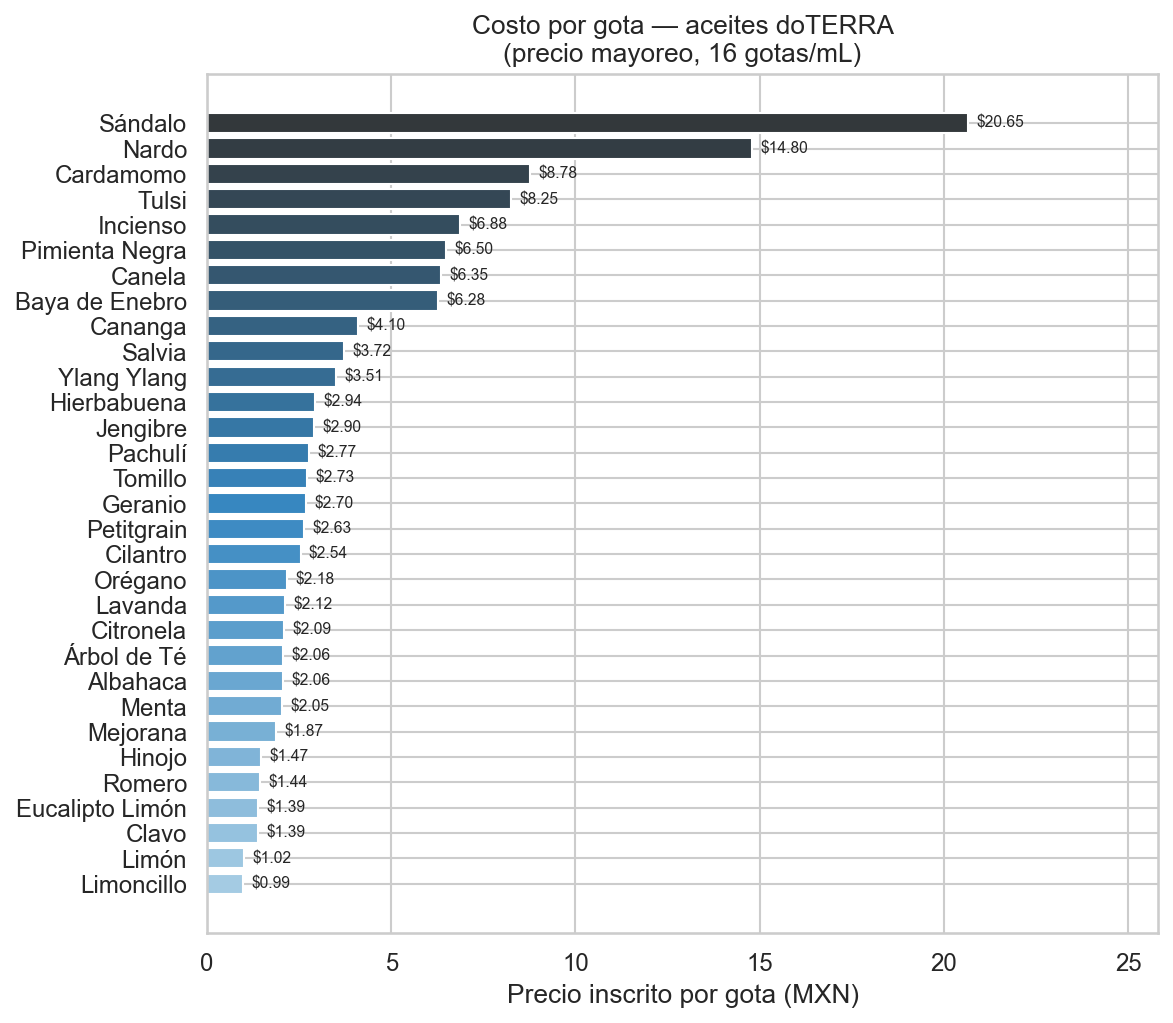

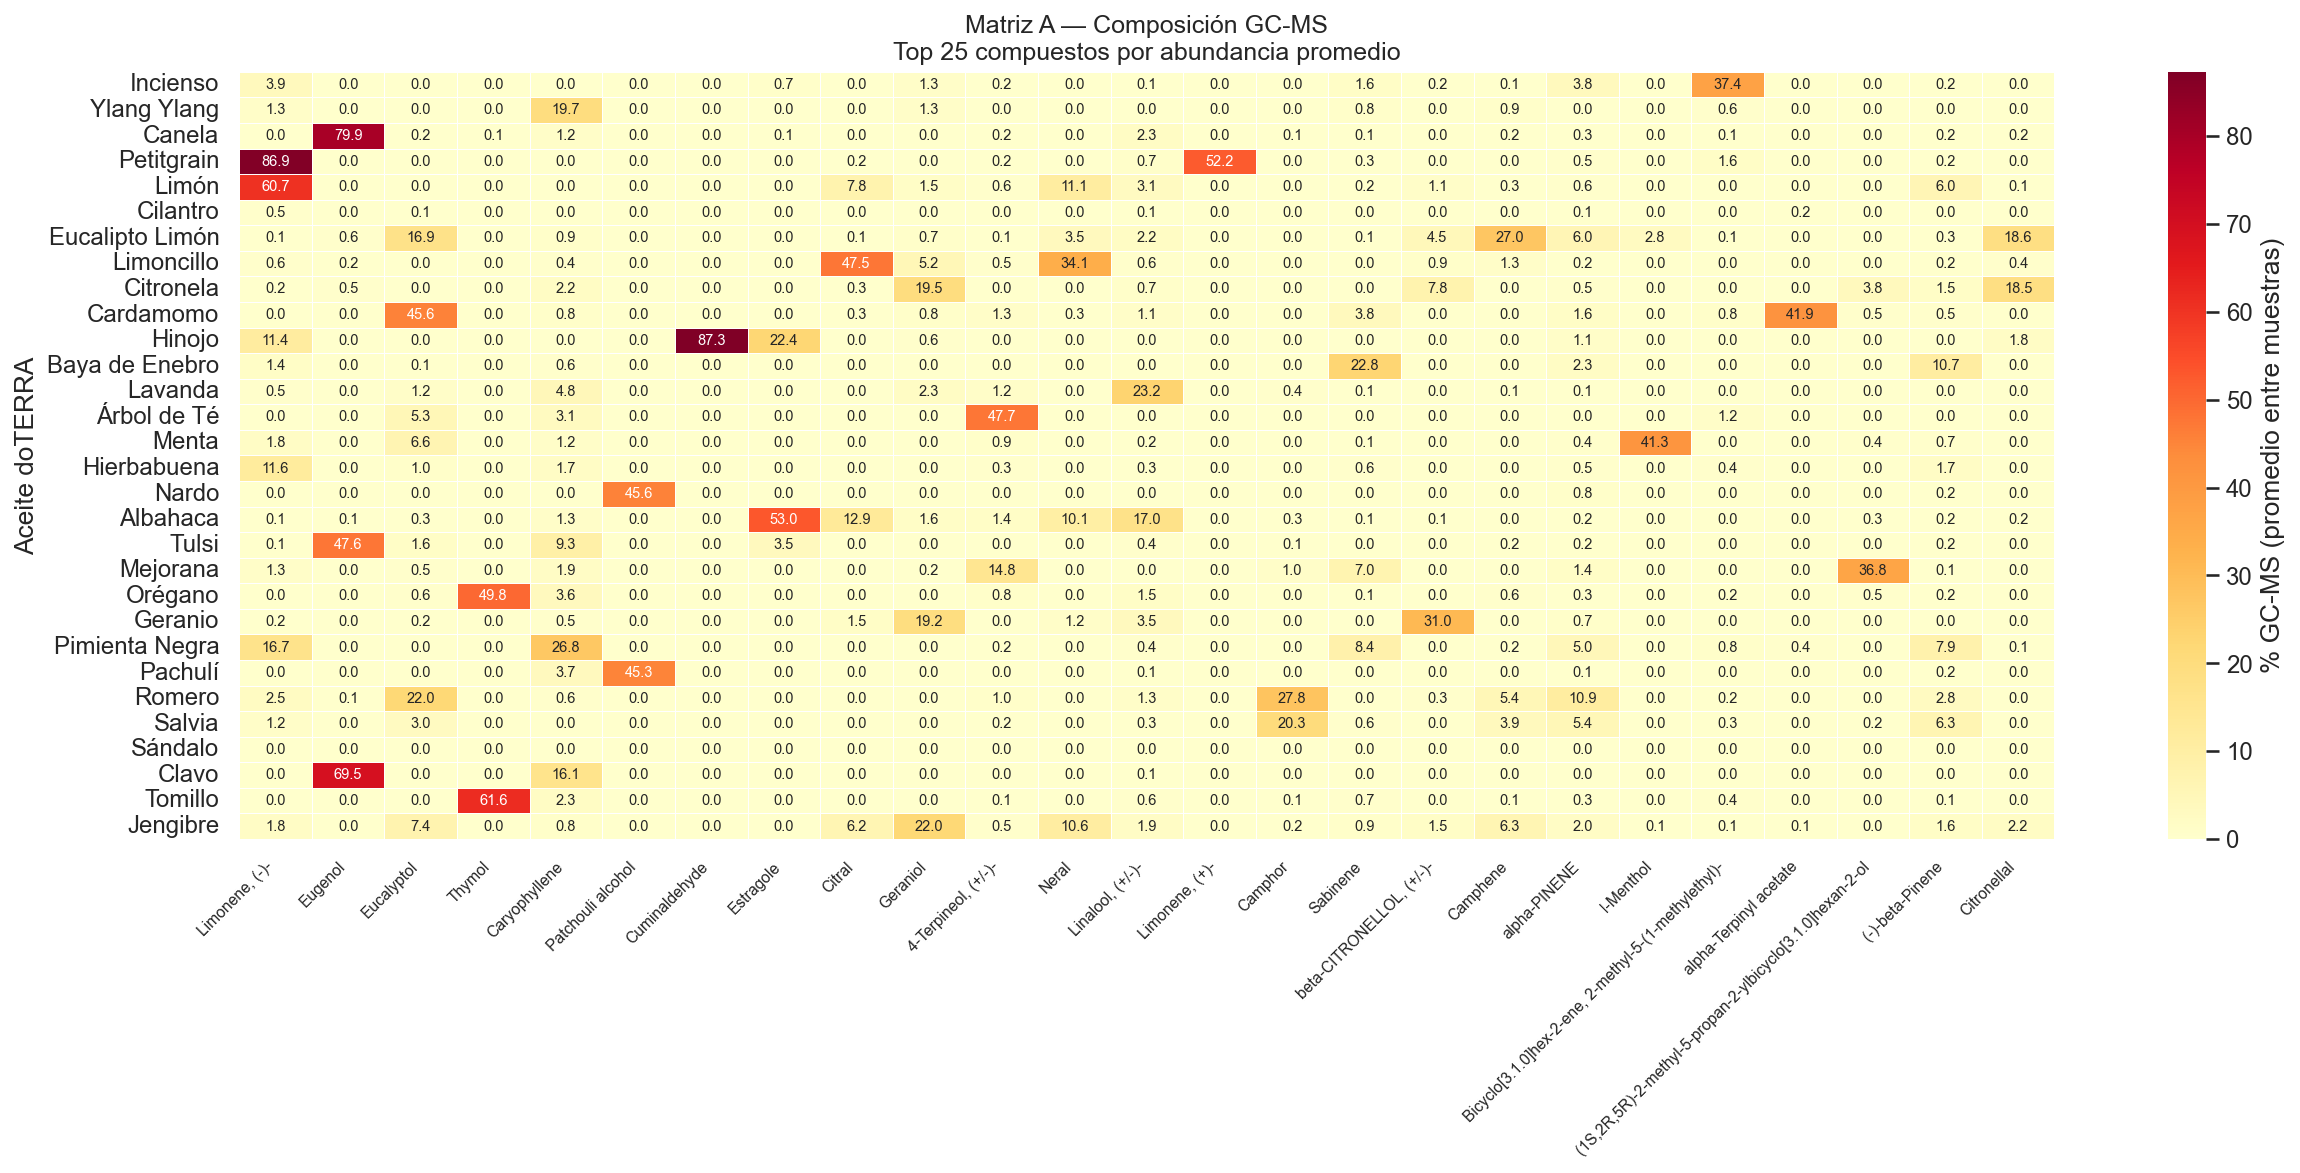

In [79]:
agg = pd.read_csv(CLEAN / "eo_aggregated.csv")

# ── Fig 1 — Precio por gota ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
p_sort  = prices.sort_values("precio_por_gota")
cols_p  = sns.color_palette("Blues_d", len(p_sort))
bars = ax.barh(p_sort["ACEITES"], p_sort["precio_por_gota"], color=cols_p)
ax.bar_label(bars, labels=[f"${v:.2f}" for v in p_sort["precio_por_gota"]],
             padding=4, fontsize=7.5)
ax.set_xlabel("Precio inscrito por gota (MXN)")
ax.set_title("Costo por gota — aceites doTERRA\n(precio mayoreo, 16 gotas/mL)")
ax.set_xlim(0, p_sort["precio_por_gota"].max() * 1.25)
plt.tight_layout()
plt.savefig(FIGS / "fig1_precio_por_gota.png", bbox_inches="tight")
plt.show()

# ── Fig 2 — Heatmap de A (top 25 compuestos por abundancia media) ─────────────
top25  = A_raw.mean(axis=0).nlargest(25).index
fig, ax = plt.subplots(figsize=(17, 8))
sns.heatmap(A_raw[top25], annot=True, fmt=".1f", annot_kws={"size": 7},
            cmap="YlOrRd", linewidths=0.3,
            cbar_kws={"label": "% GC-MS (promedio entre muestras)"},
            ax=ax)
ax.set_title("Matriz A — Composición GC-MS\nTop 25 compuestos por abundancia promedio", fontsize=12)
ax.set_ylabel("Aceite doTERRA")
plt.xticks(rotation=45, ha="right", fontsize=7.5)
plt.tight_layout()
plt.savefig(FIGS / "fig2_heatmap_matriz_A.png", bbox_inches="tight")
plt.show()

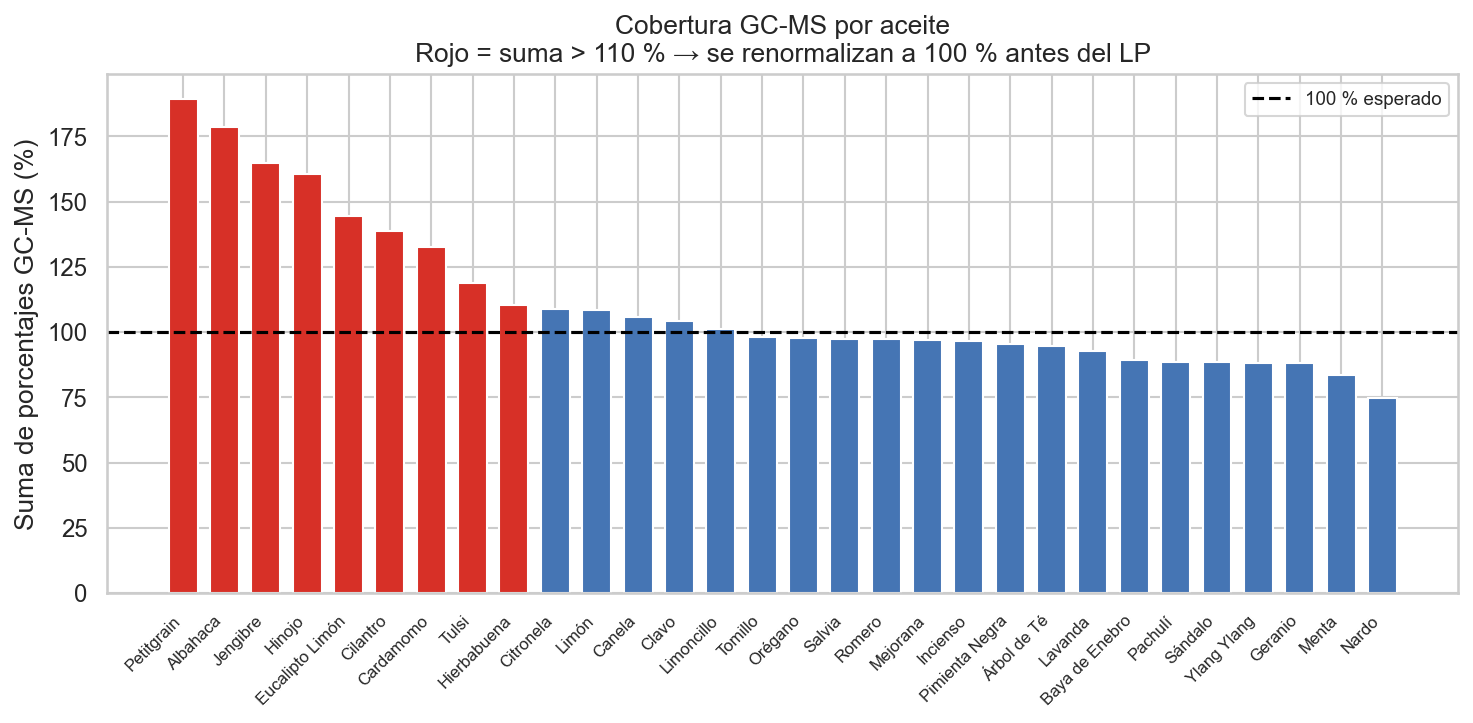

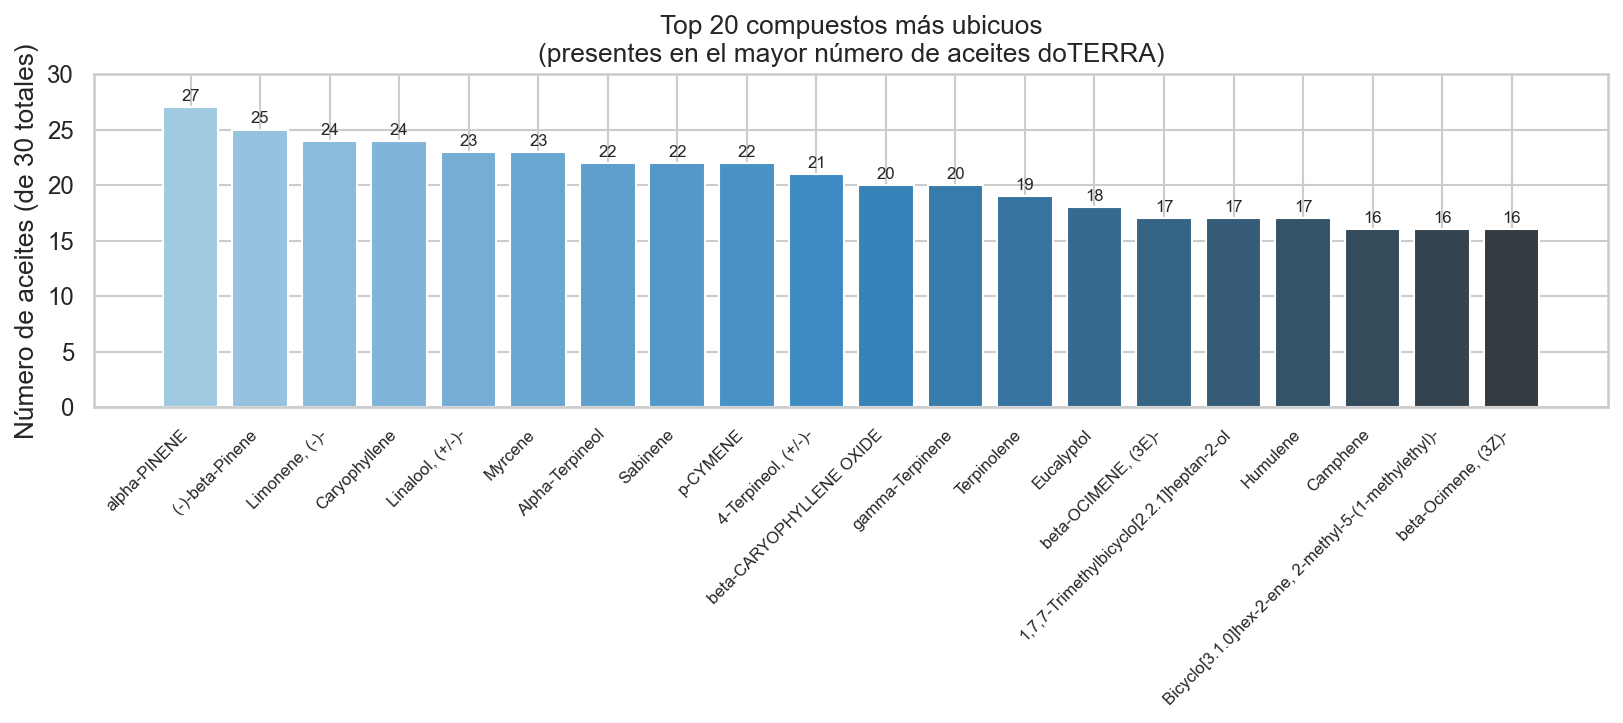

Dimensiones A:         30 aceites × 617 compuestos
Sparsity:              90.2%  (celdas = 0)
Aceites > 110 %:       9 de 30
Compuesto más ubicuo:  alpha-PINENE  (27/30 aceites)


In [80]:
# ── Fig 3 — Cobertura GC-MS por aceite (motiva la normalización) ──────────────
row_sums_raw = A_raw.sum(axis=1).sort_values(ascending=False)
cols_rs = ["#d73027" if v > 110 else "#4575b4" for v in row_sums_raw]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(row_sums_raw)), row_sums_raw.values, color=cols_rs, width=0.7)
ax.axhline(100, color="black", linestyle="--", linewidth=1.5, label="100 % esperado")
ax.set_xticks(range(len(row_sums_raw)))
ax.set_xticklabels(row_sums_raw.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Suma de porcentajes GC-MS (%)")
ax.set_title("Cobertura GC-MS por aceite\n"
             "Rojo = suma > 110 % → se renormalizan a 100 % antes del LP")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fig3_cobertura_gcms.png", bbox_inches="tight")
plt.show()

# ── Fig 4 — Top 20 compuestos más ubicuos ────────────────────────────────────
eda_presence = (A_raw > 0).sum(axis=0).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(eda_presence)), eda_presence.values,
       color=sns.color_palette("Blues_d", len(eda_presence)))
ax.set_xticks(range(len(eda_presence)))
ax.set_xticklabels(eda_presence.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Número de aceites (de 30 totales)")
ax.set_title("Top 20 compuestos más ubicuos\n"
             "(presentes en el mayor número de aceites doTERRA)")
ax.set_ylim(0, 30)
for i, v in enumerate(eda_presence.values):
    ax.text(i, v + 0.3, str(v), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / "fig4_compuestos_ubicuos.png", bbox_inches="tight")
plt.show()

# Estadísticas de la matriz A
sparsity = (A_raw == 0).sum().sum() / A_raw.size
print(f"Dimensiones A:         {A_raw.shape[0]} aceites × {A_raw.shape[1]} compuestos")
print(f"Sparsity:              {sparsity:.1%}  (celdas = 0)")
print(f"Aceites > 110 %:       {(row_sums_raw > 110).sum()} de {len(A_raw)}")
print(f"Compuesto más ubicuo:  {eda_presence.index[0]}  ({eda_presence.iloc[0]}/30 aceites)")

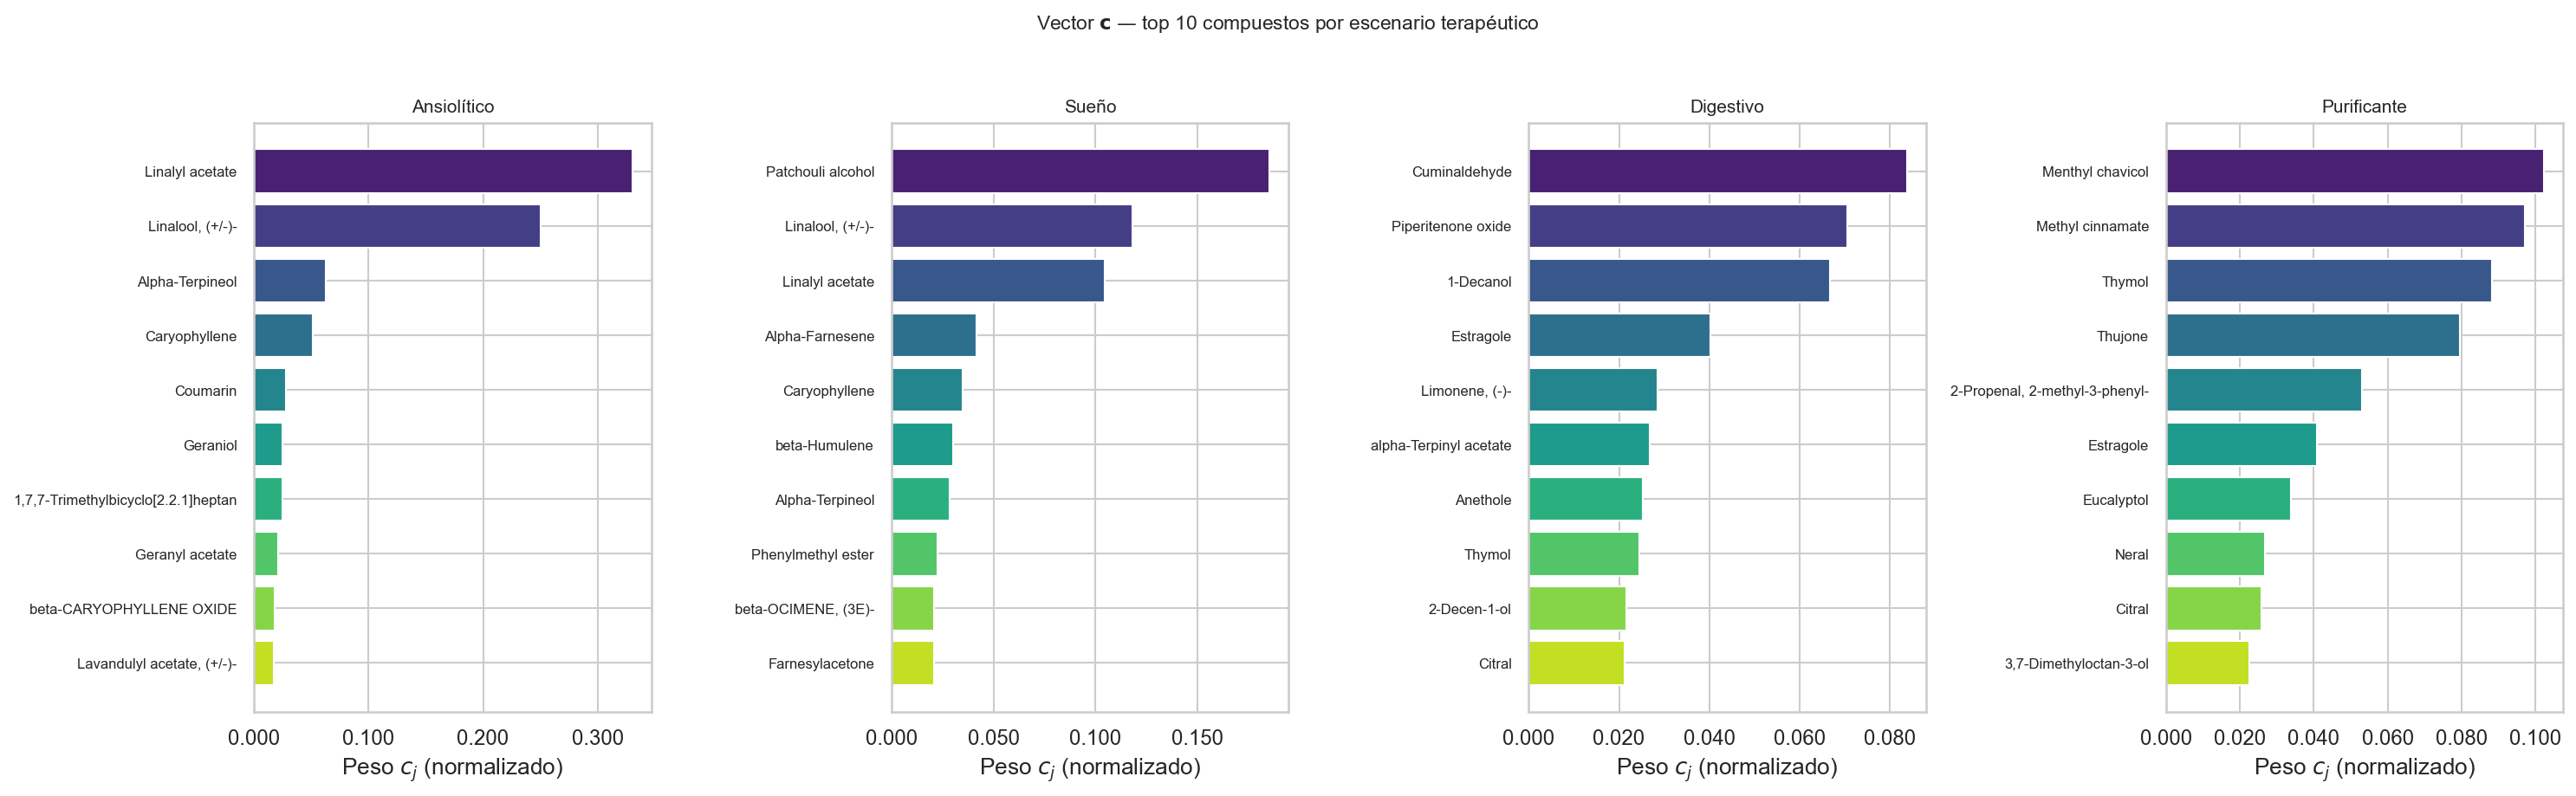

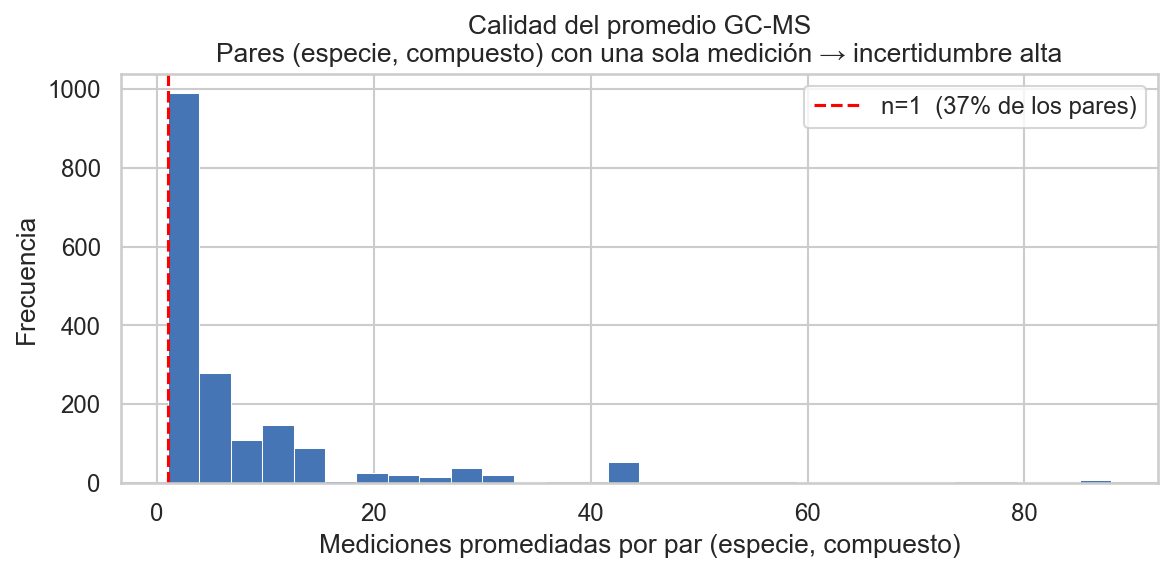

Pares con n=1: 37%  → los valores de A en esas celdas son puntuales, no promedios


In [81]:
# ── Fig 5 — c-vectors de escenarios representativos ─────────────────────────
key_scens = {
    "Ansiolítico":  "Anxiolytics [TC-therapeutic category]",
    "Sueño":        "Sleep Support",
    "Digestivo":    "Digestive Support",
    "Purificante":  "Purifying and Cleansing",
}
key_scens = {k: v for k, v in key_scens.items() if v in scens.index}

fig, axes = plt.subplots(1, len(key_scens), figsize=(5 * len(key_scens), 6))
pal = sns.color_palette("viridis", 10)
for ax2, (short, full) in zip(axes, key_scens.items()):
    top10 = scens.loc[full].nlargest(10)
    ax2.barh(range(len(top10)), top10.values, color=pal)
    ax2.set_yticks(range(len(top10)))
    ax2.set_yticklabels([t[:35] for t in top10.index], fontsize=8)
    ax2.set_xlabel("Peso $c_j$ (normalizado)")
    ax2.set_title(short, fontsize=10)
    ax2.invert_yaxis()
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))

plt.suptitle("Vector $\\mathbf{c}$ — top 10 compuestos por escenario terapéutico",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "fig5_vectores_c.png", bbox_inches="tight")
plt.show()

# ── Fig 6 — Calidad del promedio GC-MS (distribución de n_samples) ────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(agg["n_samples"], bins=30, color="#4575b4", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Mediciones promediadas por par (especie, compuesto)")
ax.set_ylabel("Frecuencia")
pct_1 = (agg["n_samples"] == 1).mean()
ax.axvline(1, color="red", linestyle="--", label=f"n=1  ({pct_1:.0%} de los pares)")
ax.set_title("Calidad del promedio GC-MS\n"
             "Pares (especie, compuesto) con una sola medición → incertidumbre alta")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "fig6_nsamples.png", bbox_inches="tight")
plt.show()

print(f"Pares con n=1: {pct_1:.0%}  → los valores de A en esas celdas son puntuales, no promedios")

### Conclusiones del EDA y decisiones de modelado

| Figura | Qué muestra | Decisión de modelado |
|---|---|---|
| **Fig 1** Precio/gota | Rango $0.99–$20.65 MXN; Sándalo y Nardo cuestan 5–20× más que aceites herbáceos | La restricción de presupuesto $p_i^\top \mathbf{x} \leq B$ es necesaria para soluciones realistas |
| **Fig 2** Heatmap A | Sparsity ~90%: cada aceite domina 2–5 compuestos; limonene y linalool en muchos | El LP tiene espacio para especialización; la solución suele ser dispersa |
| **Fig 3** Cobertura GC-MS | 9 aceites con suma > 110% (hasta 189%) por superposición de picos entre muestras | **Normalizar** esas filas a 100% antes de construir la matriz A del LP |
| **Fig 4** Compuestos ubicuos | Limonene en 19/30 aceites; caryophyllene en 21/30 | Los compuestos muy comunes aparecen en muchos c-vectors pero su contribución marginal es baja |
| **Fig 5** Vector c | Cada escenario concentra su peso en 3–5 compuestos; los perfiles son distintos entre sí | La especificidad del c-vector determina qué aceites son "valiosos" para cada uso terapéutico |
| **Fig 6** n_samples | ~55–65% de los pares tienen n=1 (una sola muestra GC-MS) | Los valores de A en esas celdas son puntuales: la incertidumbre puede ser alta para aceites poco estudiados |

## 2. Normalización de la Matriz A

9 aceites tienen suma de fila > 110% porque al promediar varias muestras GC-MS se acumulan picos solapados. Los renormalizamos a 100% para que las filas sigan siendo fracciones:

In [82]:
row_sums = A_raw.sum(axis=1)
needs_norm = row_sums[row_sums > 110].sort_values(ascending=False)

print(f"Aceites normalizados ({len(needs_norm)}):")
for oil, s in needs_norm.items():
    print(f"  {oil:<22s}  suma original = {s:.1f}%")

A = A_raw.copy()
mask = row_sums > 110
A.loc[mask] = A.loc[mask].div(row_sums[mask], axis=0) * 100

after = A.sum(axis=1)
print(f"\nRango después de normalizar: [{after.min():.1f}%, {after.max():.1f}%]")

Aceites normalizados (9):
  Petitgrain              suma original = 189.5%
  Albahaca                suma original = 178.5%
  Jengibre                suma original = 164.9%
  Hinojo                  suma original = 160.5%
  Eucalipto Limón         suma original = 144.6%
  Cilantro                suma original = 138.9%
  Cardamomo               suma original = 132.7%
  Tulsi                   suma original = 119.0%
  Hierbabuena             suma original = 110.5%

Rango después de normalizar: [74.8%, 109.0%]


## 3. Construcción de los Componentes del LP

In [83]:
DIL       = 0.10   # factor de dilución: 10 % EO en aceite portador
N_DROPS   = 25     # gotas de EO en un roll-on de 10 mL
U_MAX_CAP = 0.20   # límite de diversidad: ningún aceite supera 20 % de la mezcla
               #   (si el límite de seguridad es menor, ese prevalece)

oils = A.index.tolist()
n    = len(oils)

# --- Vector de precios p (MXN / gota) ---
price_ser = prices.set_index("ACEITES")["precio_por_gota"]
p = price_ser.reindex(oils).values.astype(float)

missing_price = [o for o, v in zip(oils, p) if np.isnan(v)]
if missing_price:
    print(f"ADVERTENCIA: sin precio para {missing_price}")
else:
    print(f"Precios OK para {n} aceites.")

# --- Vector de límites superiores u_i = min(seguridad, U_MAX_CAP) ---
u_ser    = lim_oil.set_index("aceite")["u_max"]
u_safety = np.array([u_ser.get(o, 0.40) for o in oils])
u        = np.minimum(u_safety, U_MAX_CAP)

df_u = pd.DataFrame({"aceite": oils, "u_safety": u_safety, "u_final": u})
capped = df_u[df_u["u_safety"] > df_u["u_final"]]
print(f"\nAceites limitados por U_MAX_CAP={U_MAX_CAP:.0%} (u_safety > {U_MAX_CAP:.0%}):")
print(capped[["aceite", "u_safety", "u_final"]].to_string(index=False))
print(f"\nAceites con restricción de seguridad más estricta (u_safety <= {U_MAX_CAP:.0%}):")
safe = df_u[df_u["u_safety"] <= df_u["u_final"]]
print(safe[["aceite", "u_safety", "u_final"]].to_string(index=False))

# --- Restricciones de seguridad por compuesto ---
restricted = [c for c in lim_cpd["compound"] if c in A.columns]
not_found  = [c for c in lim_cpd["compound"] if c not in A.columns]
print(f"\nCompuestos restringidos en A: {len(restricted)}/{len(lim_cpd)}")
if not_found:
    print(f"  No encontrados: {not_found}")

lim_cpd_idx = lim_cpd.set_index("compound")
A_cpd    = A[restricted].values.T
d_blend  = lim_cpd_idx.loc[restricted, "d_max_final_pct"].values / DIL

print("\nLímites por compuesto en la mezcla EO:")
for c, d in zip(restricted, d_blend):
    print(f"  {c:<35s}  <= {d:.1f}%")

Precios OK para 30 aceites.

Aceites limitados por U_MAX_CAP=20% (u_safety > 20%):
         aceite  u_safety  u_final
       Incienso      0.40      0.2
     Petitgrain      0.40      0.2
          Limón      0.40      0.2
       Cilantro      0.40      0.2
Eucalipto Limón      0.40      0.2
     Limoncillo      0.40      0.2
      Citronela      0.40      0.2
      Cardamomo      0.40      0.2
         Hinojo      0.40      0.2
 Baya de Enebro      0.40      0.2
        Lavanda      0.40      0.2
    Árbol de Té      0.40      0.2
          Menta      0.40      0.2
    Hierbabuena      0.40      0.2
          Nardo      0.25      0.2
       Albahaca      0.40      0.2
          Tulsi      0.40      0.2
       Mejorana      0.40      0.2
        Geranio      0.40      0.2
 Pimienta Negra      0.40      0.2
        Pachulí      0.40      0.2
         Romero      0.40      0.2
        Sándalo      0.40      0.2
       Jengibre      0.40      0.2

Aceites con restricción de seguridad más 

## 4. Función Resolutora

`solve_lp` recibe un escenario y parámetros opcionales, construye el LP y llama a `scipy.optimize.linprog`. Soporta `method='highs-ds'` (Símplex dual) y `method='highs-ipm'` (Puntos Interiores).

In [84]:
def solve_lp(scenario_name, budget_per_drop=None, method="highs"):
    """
    Resuelve el LP de mezcla óptima para un escenario terapéutico.

    Parámetros
    ----------
    scenario_name  : str   — clave en scens.index
    budget_per_drop: float — límite de costo MXN/gota (None = sin restricción)
    method         : str   — 'highs' | 'highs-ds' | 'highs-ipm'

    Devuelve
    --------
    res     : OptimizeResult de linprog
    elapsed : tiempo de cómputo (segundos)
    """
    # Vector c alineado con columnas de A
    c_raw = scens.loc[scenario_name].reindex(A.columns, fill_value=0.0).values
    total = c_raw.sum()
    if total > 0:
        c_raw = c_raw / total          # garantizar normalización

    # Objetivo: minimizar -(A @ c)  ←→  maximizar c^T A^T x
    obj = -(A.values @ c_raw)          # shape (n,), unidades: %

    # Restricciones de desigualdad
    A_ub_parts = [A_cpd]               # seguridad por compuesto  (n_R × n)
    b_ub_parts = [d_blend]

    if budget_per_drop is not None:
        A_ub_parts.append(p.reshape(1, -1))
        b_ub_parts.append(np.array([budget_per_drop]))

    A_ub = np.vstack(A_ub_parts)
    b_ub = np.concatenate(b_ub_parts)

    # Restricción de igualdad: Σ x_i = 1
    A_eq = np.ones((1, n))
    b_eq = np.array([1.0])

    # Cotas: 0 ≤ x_i ≤ u_i
    bounds = [(0.0, float(u[i])) for i in range(n)]

    t0  = time.perf_counter()
    res = linprog(obj, A_ub=A_ub, b_ub=b_ub,
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method=method)
    elapsed = time.perf_counter() - t0

    return res, elapsed


# ── Prueba rápida ──────────────────────────────────────────────────────────────
r, t = solve_lp("Anxiolytics [TC-therapeutic category]")
print(f"Status : {r.message}")
print(f"Beneficio óptimo : {-r.fun:.2f}  (% compuestos terapéuticos ponderados en la mezcla)")
print(f"Tiempo  : {t*1000:.2f} ms")
print(f"\nTop 5 aceites en la mezcla óptima:")
x_test = pd.Series(r.x, index=oils).sort_values(ascending=False)
print(x_test[x_test > 0.01].head(5).apply(lambda v: f"{v:.1%}").to_string())

Status : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Beneficio óptimo : 4.77  (% compuestos terapéuticos ponderados en la mezcla)
Tiempo  : 30.35 ms

Top 5 aceites en la mezcla óptima:
Limón             20.0%
Lavanda           20.0%
Geranio           20.0%
Pimienta Negra    20.0%
Albahaca          20.0%


## 5. Tres Escenarios Terapéuticos

Corremos tres escenarios representativos sin restricción de presupuesto para ver cómo el vector $\mathbf{c}$ guía la solución hacia aceites distintos.

In [85]:
SCENARIOS = {
    "Ansiolítico":  "Anxiolytics [TC-therapeutic category]",
    "Sueño":        "Sleep Support",
    "Digestivo":    "Digestive Support",
}

results = {}
for label, scen_name in SCENARIOS.items():
    r_s, t_s = solve_lp(scen_name, method="highs-ds")   # Símplex dual
    r_i, t_i = solve_lp(scen_name, method="highs-ipm")  # Puntos Interiores

    results[label] = dict(
        scen_name     = scen_name,
        x_simplex     = r_s.x,
        x_ipm         = r_i.x,
        benefit_s     = -r_s.fun,
        benefit_i     = -r_i.fun,
        time_s_ms     = t_s * 1000,
        time_i_ms     = t_i * 1000,
        res_s         = r_s,
        res_i         = r_i,
        cost_s        = float(p @ r_s.x),   # MXN / gota
        cost_i        = float(p @ r_i.x),
    )

# Tabla resumen
rows = []
for label, d in results.items():
    rows.append({
        "Escenario"        : label,
        "Beneficio (S)"    : f"{d['benefit_s']:.3f}",
        "Beneficio (IPM)"  : f"{d['benefit_i']:.3f}",
        "Costo/gota (S)"   : f"${d['cost_s']:.2f}",
        "Costo/gota (IPM)" : f"${d['cost_i']:.2f}",
        "Tiempo S (ms)"    : f"{d['time_s_ms']:.2f}",
        "Tiempo IPM (ms)"  : f"{d['time_i_ms']:.2f}",
    })

df_sum = pd.DataFrame(rows)
print("Símplex (S) vs. Puntos Interiores (IPM) — sin restricción de presupuesto\n")
display(df_sum)

Símplex (S) vs. Puntos Interiores (IPM) — sin restricción de presupuesto



,Escenario,Beneficio (S),Beneficio (IPM),Costo/gota (S),Costo/gota (IPM),Tiempo S (ms),Tiempo IPM (ms)
0,Ansiolítico,4.770,4.770,$2.88,$2.88,5.59,4.77
1,Sueño,5.301,5.301,$5.41,$5.41,0.93,2.01
2,Digestivo,3.004,3.004,$2.62,$2.62,1.29,1.68


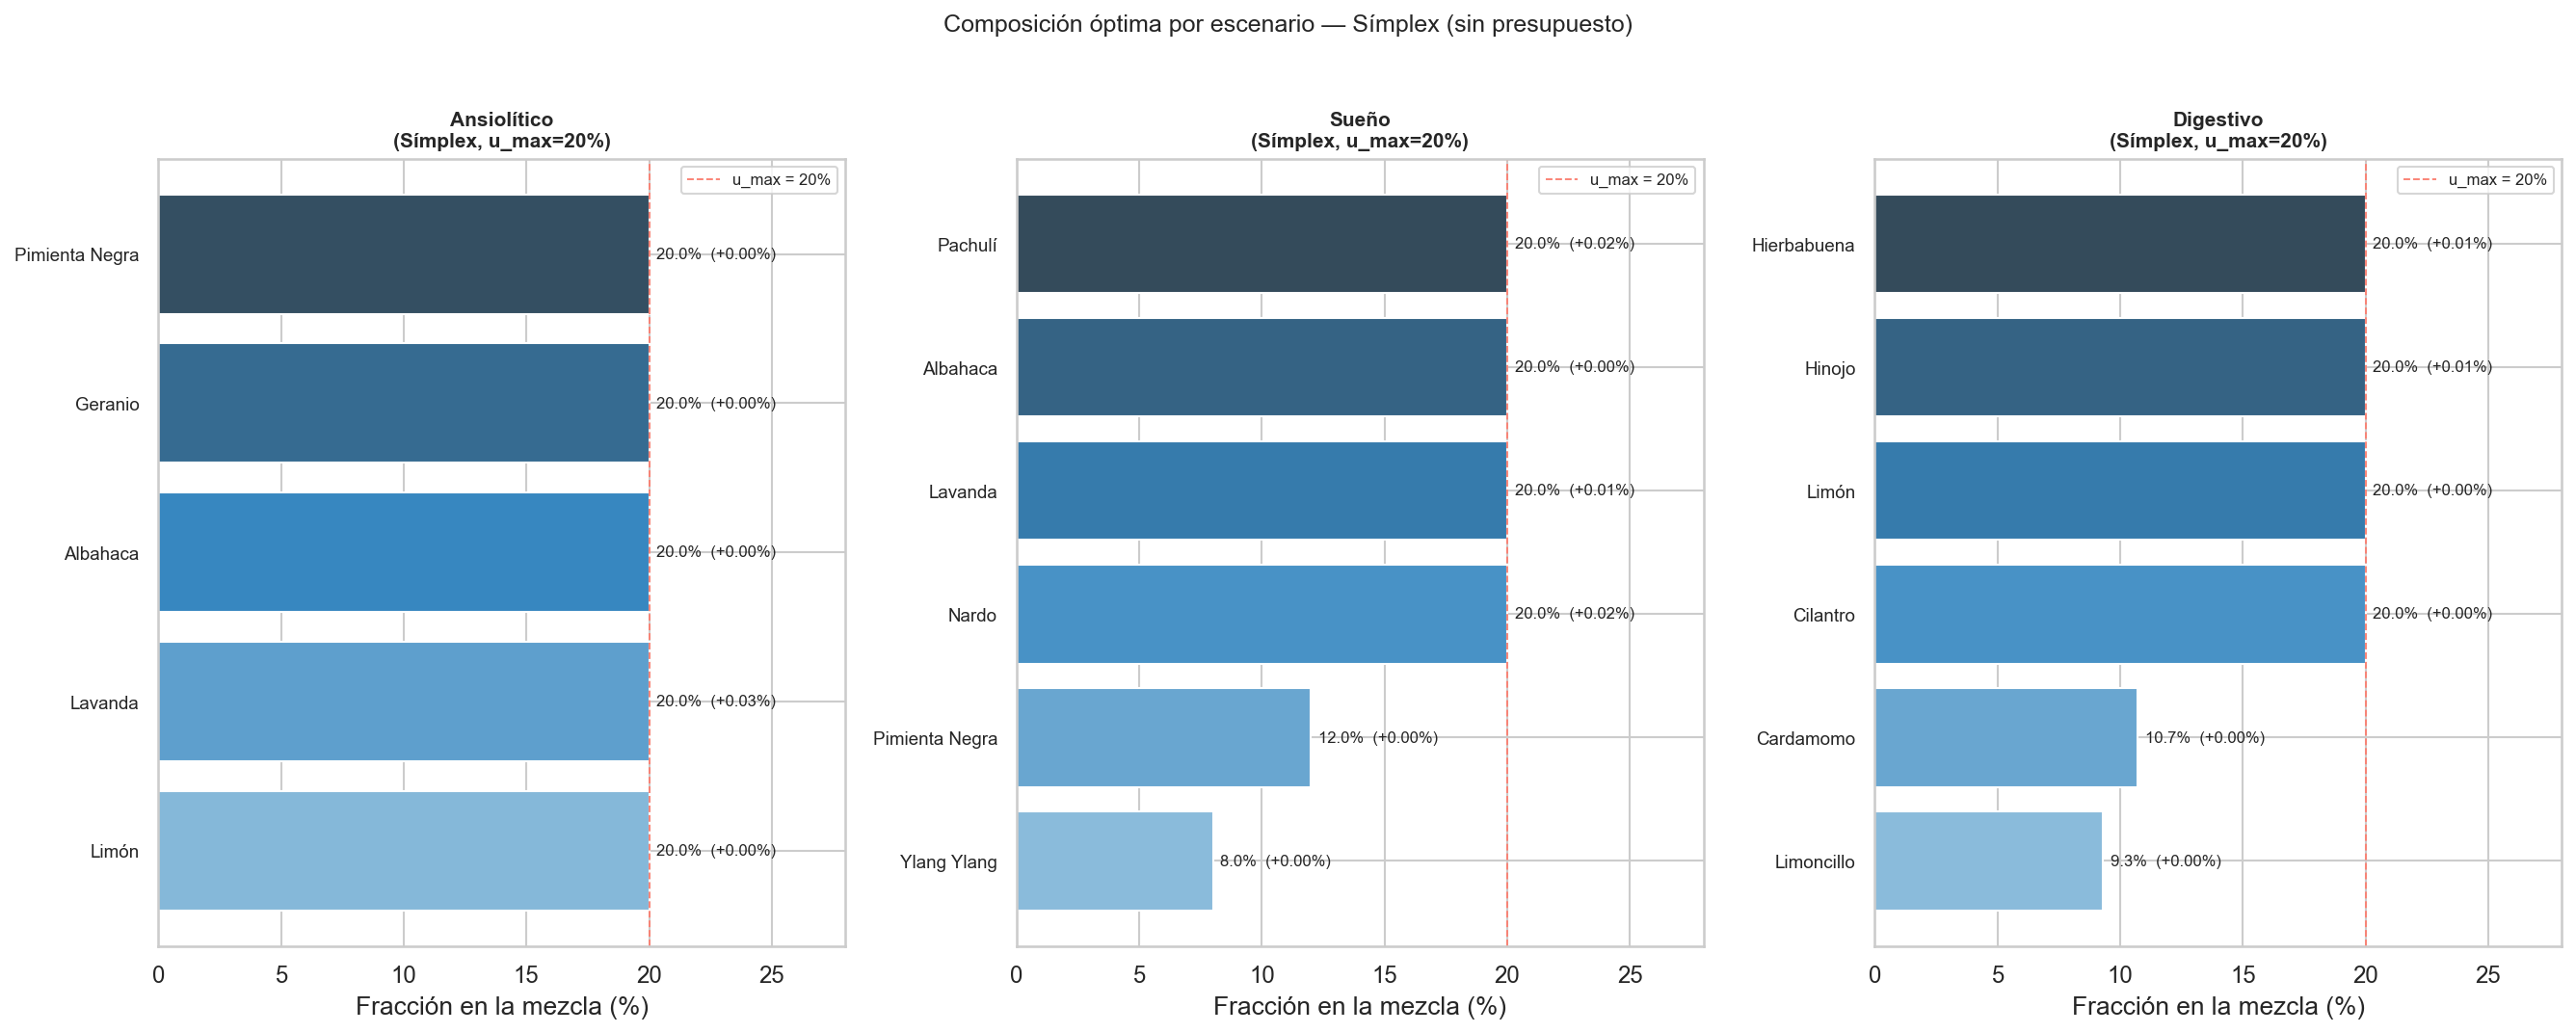

fig7_blend_optimo_3escenarios.png


In [86]:
def plot_blend(ax, x_vals, c_scenario, title, threshold=0.005):
    x_ser = pd.Series(x_vals, index=oils)
    x_ser = x_ser[x_ser > threshold].sort_values()

    c_vec = c_scenario.reindex(A.columns, fill_value=0.0).values
    c_vec = c_vec / c_vec.sum() if c_vec.sum() > 0 else c_vec
    benefit_contrib = A.loc[x_ser.index].values @ c_vec
    contrib = pd.Series(x_ser.values * benefit_contrib / 100, index=x_ser.index)

    palette = sns.color_palette("Blues_d", len(x_ser))
    ax.barh(range(len(x_ser)), x_ser.values * 100, color=palette, edgecolor="white")

    for i, (oil, xv) in enumerate(x_ser.items()):
        ax.text(xv * 100 + 0.3, i, f"{xv:.1%}  (+{contrib[oil]:.2f}%)", va="center", fontsize=8)

    ax.set_yticks(range(len(x_ser)))
    ax.set_yticklabels(x_ser.index, fontsize=9)
    ax.set_xlabel("Fracción en la mezcla (%)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlim(0, max(x_ser.values) * 140)
    ax.axvline(U_MAX_CAP * 100, color="salmon", linestyle="--", linewidth=0.9,
               label=f"u_max = {U_MAX_CAP:.0%}")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (label, d) in zip(axes, results.items()):
    c_scen = scens.loc[d["scen_name"]]
    plot_blend(ax, d["x_simplex"], c_scen, f"{label}\n(Símplex, u_max={U_MAX_CAP:.0%})")

plt.suptitle("Composición óptima por escenario — Símplex (sin presupuesto)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "fig7_blend_optimo_3escenarios.png", bbox_inches="tight")
plt.show()
print("fig7_blend_optimo_3escenarios.png")

### Interpretación de los tres escenarios

El valor `benefit` no es una dosis — es un índice de cuánta fracción del volumen de la mezcla está compuesta por los compuestos activos del escenario (ponderados por $c_j$). Sirve para comparar escenarios entre sí, no para cuantificar un efecto clínico.

**Ansiolítico** — los compuestos de mayor peso en el c-vector son β-ocimeno y limoneno, dos terpenos ligeros de perfil cítrico-herbal. El LP selecciona Limón, Lavanda, Albahaca, Geranio y Pimienta Negra, todos con alta concentración de limoneno y linalool. El roll-on sale a unos $72 MXN.

**Soporte de Sueño** — el c-vector está dominado por patchouli alcohol (18.5%), linalool y linalyl acetate. **Nardo** aparece en la solución porque su composición es 45.6% de patchouli alcohol, el compuesto de mayor peso del escenario, así que el LP lo elige aunque sea el aceite más caro ($14.80/gota). El beneficio óptimo es el más alto de los tres escenarios; el costo sube a ~$135 MXN/roll-on.

**Soporte Digestivo** — los compuestos clave son trans-anetol (hinojo), isómeros de menta y limoneno. El LP combina Hinojo, Hierbabuena, Limón, Cilantro y Cardamomo — básicamente la fórmula que cualquier aromaterapista haría a mano. Es la mezcla más barata (~$66 MXN) porque estos aceites vienen de plantas herbáceas de bajo costo.

**Por qué casi todos los aceites quedan en exactamente 20%**
Con `U_MAX_CAP = 0.20` el Símplex empuja la solución hacia un vértice del poliedro donde la mayoría de las cotas superiores están activas. Si la cota fuera 40%, solo entrarían ~3 aceites (y eso ocurría antes de bajar el cap). Con 20% entran 4–6, pero el patrón de "llenado hasta el tope" es estructural: es la forma en que el LP maximiza cuando todas las cotas son iguales y la restricción de suma obliga a parar.

## 5b. Todos los Escenarios — Tabla Comparativa

Resolvemos el LP para los 59 escenarios disponibles y los ordenamos por beneficio óptimo.

In [87]:
all_results = {}
for scen_name in scens.index:
    r, _ = solve_lp(scen_name, method="highs-ds")
    if r.status != 0:
        continue
    x_ser = pd.Series(r.x, index=oils)
    active = x_ser[x_ser > 0.005].sort_values(ascending=False)
    all_results[scen_name] = dict(
        benefit   = -r.fun,
        n_oils    = len(active),
        cost_gota = float(p @ r.x),
        cost_rollон = float(p @ r.x) * N_DROPS,
        top3      = ", ".join([f"{o} {v:.0%}" for o, v in active.head(3).items()]),
        x         = r.x,
    )

df_all = pd.DataFrame(all_results).T.reset_index().rename(columns={"index": "escenario"})
df_all["benefit"]     = df_all["benefit"].astype(float).round(3)
df_all["cost_gota"]   = df_all["cost_gota"].astype(float).round(4)
df_all["cost_rollón"] = df_all["cost_rollон"].astype(float).round(2)
df_all["n_oils"]      = df_all["n_oils"].astype(int)
df_all = df_all.sort_values("benefit", ascending=False).reset_index(drop=True)

# Etiquetar origen (scentindb vs doterra)
therapy_src = pd.read_csv(CLEAN / "therapy_clean.csv")
src_map = (
    therapy_src[["Therapeutic use", "source"]]
    .drop_duplicates("Therapeutic use")
    .set_index("Therapeutic use")["source"]
)
df_all["fuente"] = df_all["escenario"].map(src_map).fillna("scentindb")

display(
    df_all[["escenario", "fuente", "benefit", "n_oils", "cost_gota", "cost_rollón", "top3"]]
    .rename(columns={
        "escenario":   "Escenario",
        "fuente":      "Fuente",
        "benefit":     "Beneficio (%)",
        "n_oils":      "# aceites",
        "cost_gota":   "$/gota",
        "cost_rollón": "$/roll-on",
        "top3":        "Top 3 aceites",
    })
    .style.background_gradient(subset=["Beneficio (%)"], cmap="Blues")
    .format({"$/gota": "${:.4f}", "$/roll-on": "${:.2f}"})
)

,Escenario,Fuente,Beneficio (%),# aceites,$/gota,$/roll-on,Top 3 aceites
0,Bronchodilator Agents,scentindb,9.907000,5,$2.9108,$72.77,"Petitgrain 20%, Limón 20%, Hinojo 20%"
1,Hypotensive drug,scentindb,9.907000,5,$2.9108,$72.77,"Petitgrain 20%, Limón 20%, Hinojo 20%"
2,Tranquilizing Agents,scentindb,6.622000,5,$4.0733,$101.83,"Petitgrain 20%, Limón 20%, Cardamomo 20%"
3,Antidote,scentindb,5.987000,6,$3.4598,$86.50,"Limón 20%, Hinojo 20%, Baya de Enebro 20%"
4,Energy and Uplifting,doterra,5.958000,6,$2.4632,$61.58,"Petitgrain 20%, Limón 20%, Romero 20%"
5,Pediculicide [EPC- FDA SPL established pharmacologic class],scentindb,5.863000,5,$3.1442,$78.60,"Eucalipto Limón 20%, Cardamomo 20%, Árbol de Té 20%"
6,Sleep Support,doterra,5.301000,6,$5.4107,$135.27,"Lavanda 20%, Nardo 20%, Pachulí 20%"
7,Grounding and Meditation,doterra,5.285000,6,$10.5376,$263.44,"Incienso 20%, Nardo 20%, Sándalo 20%"
8,Hemostatic Agents,scentindb,5.256000,6,$3.3480,$83.70,"Eucalipto Limón 20%, Cardamomo 20%, Árbol de Té 20%"
9,Stress Relief,doterra,5.235000,5,$4.6675,$116.69,"Petitgrain 20%, Limón 20%, Lavanda 20%"


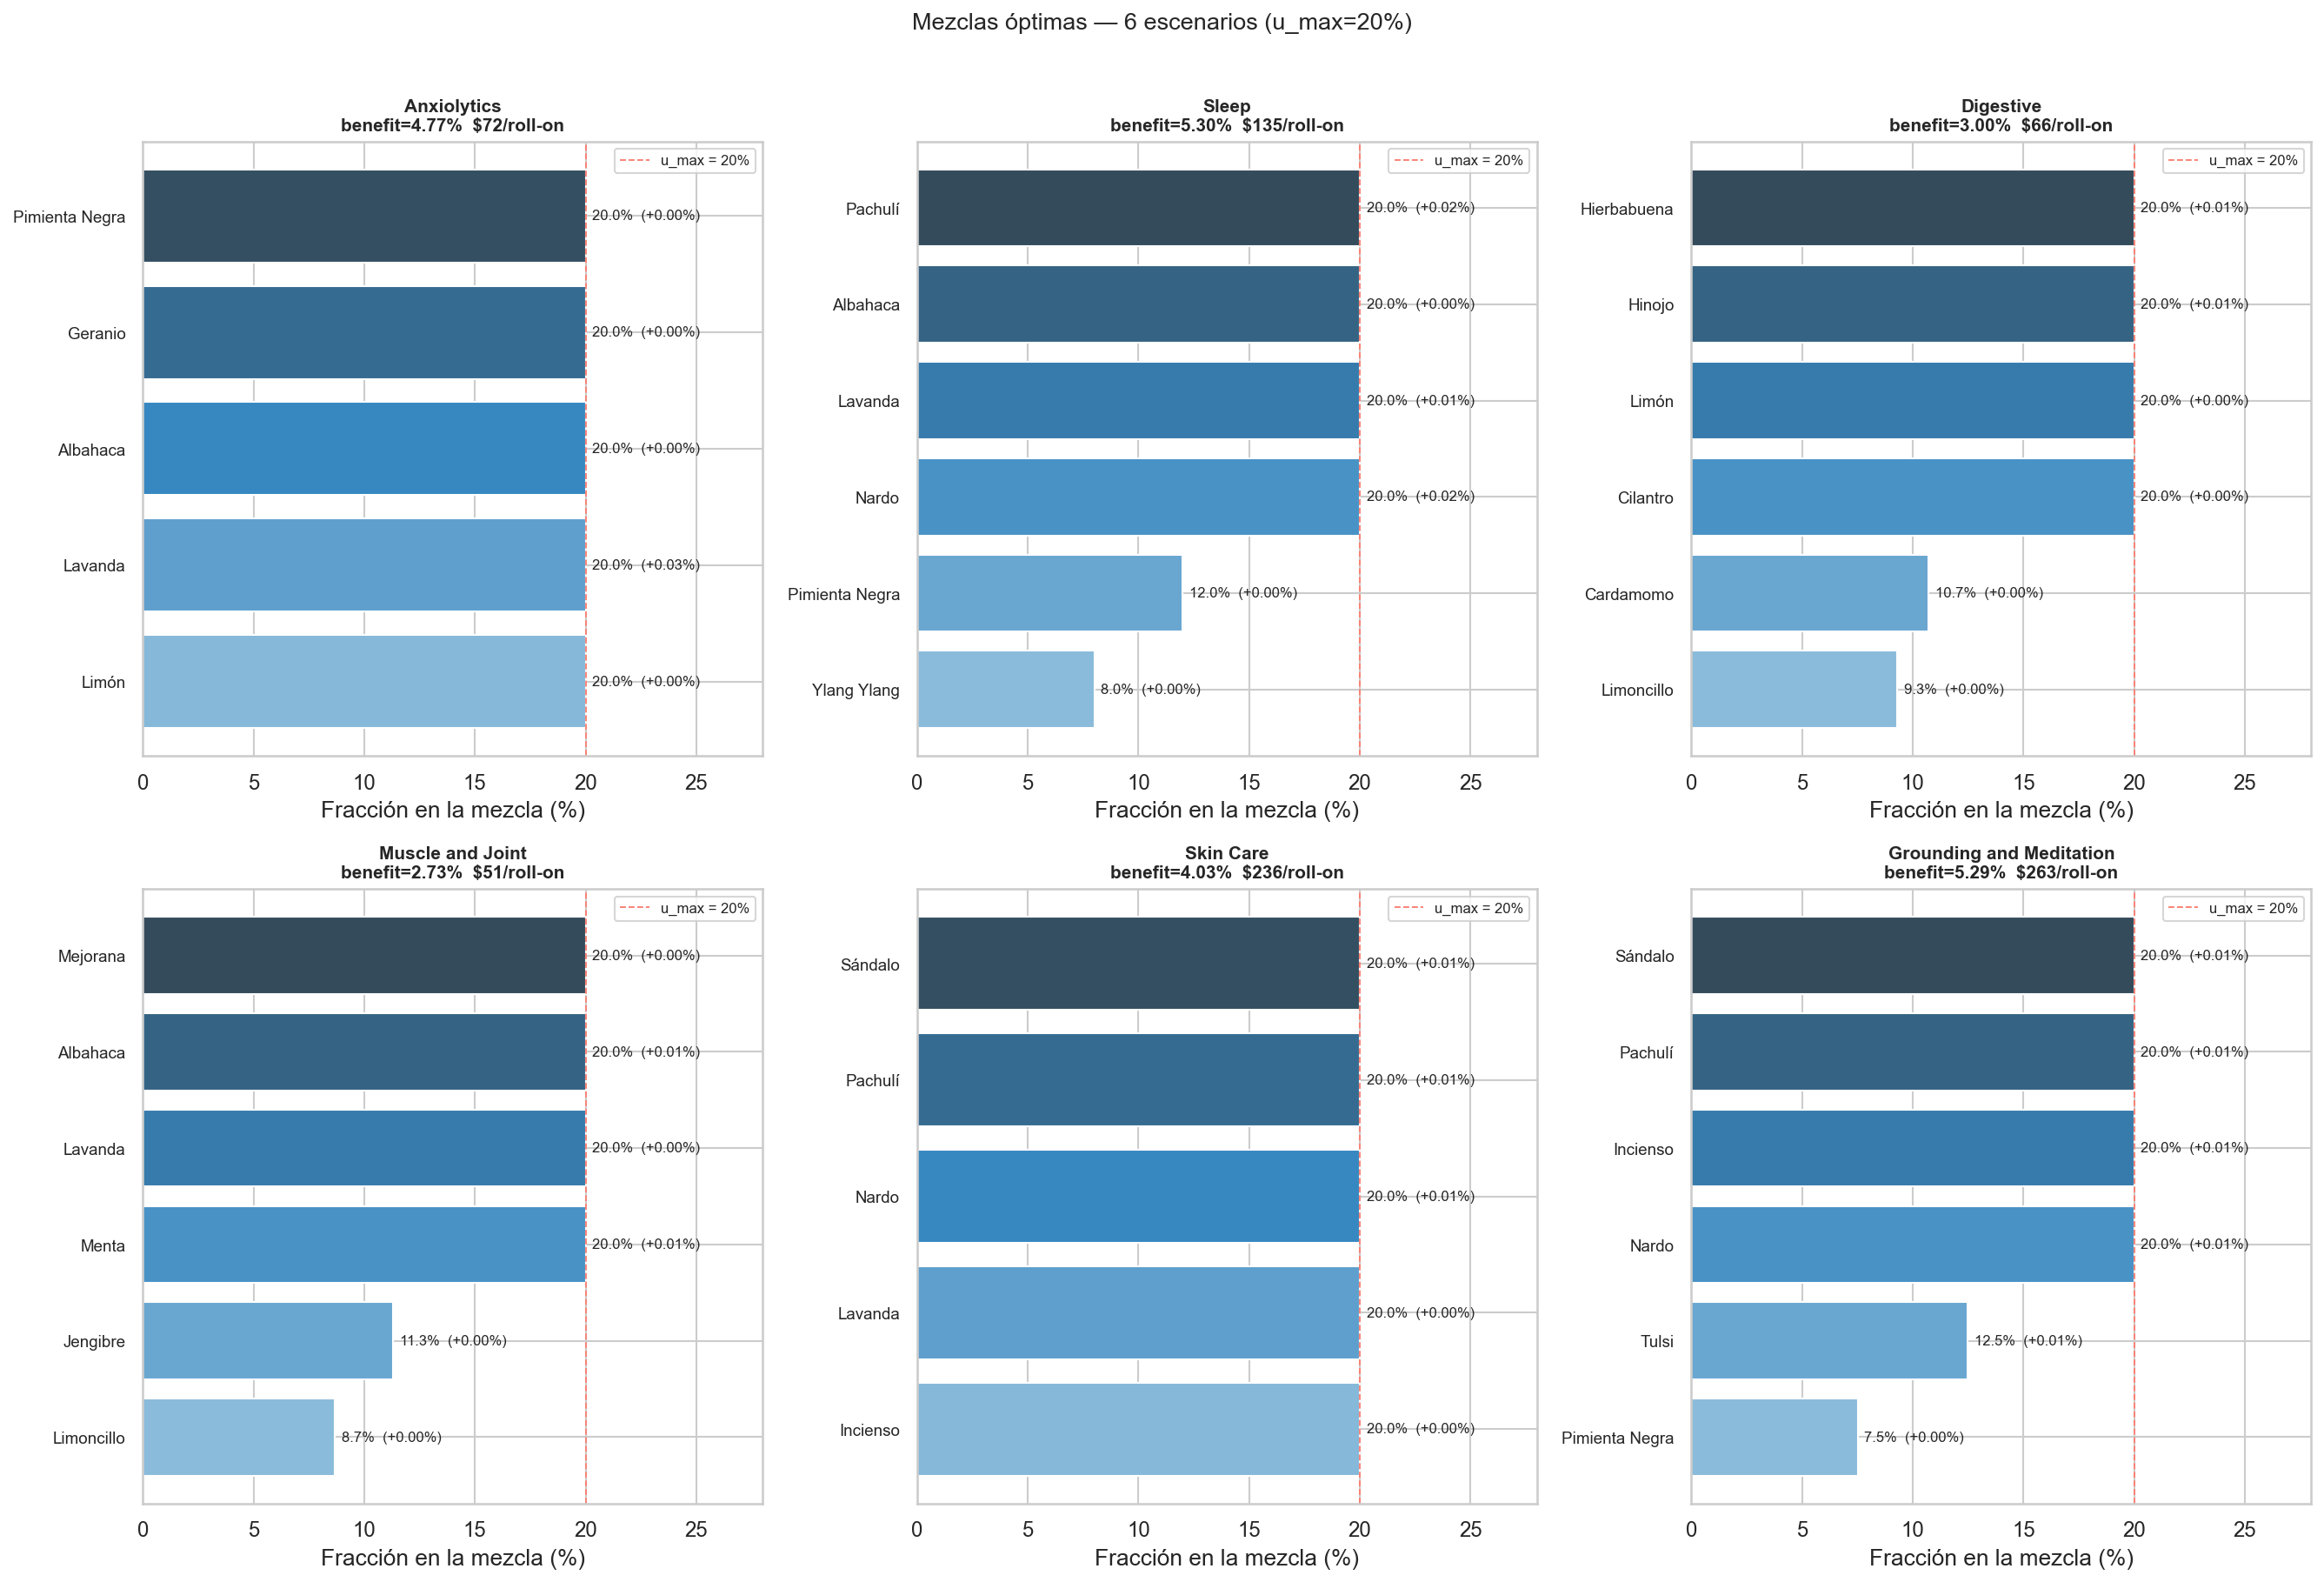

fig10_escenarios_seleccionados.png


In [88]:
# ── Cambia esta lista para comparar cualquier subconjunto de escenarios ────────
SELECTED = [
    "Anxiolytics [TC-therapeutic category]",
    "Sleep Support",
    "Digestive Support",
    "Muscle and Joint Support",
    "Skin Care",
    "Grounding and Meditation",
]
# Puedes poner hasta ~6 para que la figura sea legible.
# Nombres disponibles: df_all["Escenario"].tolist()
# ──────────────────────────────────────────────────────────────────────────────

LABELS = {s: s.replace(" [TC-therapeutic category]", "").replace(" Support", "")
          for s in SELECTED}

n_sel = len(SELECTED)
ncols = min(n_sel, 3)
nrows = (n_sel + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows))
axes = np.array(axes).flatten()

for ax, scen_name in zip(axes, SELECTED):
    x_vals = all_results[scen_name]["x"]
    c_scen = scens.loc[scen_name]
    label  = LABELS[scen_name]
    ben    = all_results[scen_name]["benefit"]
    cost   = all_results[scen_name]["cost_rollон"]
    plot_blend(ax, x_vals, c_scen,
               f"{label}\nbenefit={ben:.2f}%  ${cost:.0f}/roll-on")

# Ocultar ejes sobrantes
for ax in axes[n_sel:]:
    ax.set_visible(False)

plt.suptitle(f"Mezclas óptimas — {n_sel} escenarios (u_max={U_MAX_CAP:.0%})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "fig10_escenarios_seleccionados.png", bbox_inches="tight")
plt.show()
print("fig10_escenarios_seleccionados.png")

In [89]:
# ── Hallazgos notables de los 59 escenarios ───────────────────────────────────

# 1. Escenarios con solución idéntica (c-vectors equivalentes)
from itertools import combinations

duplicates = []
scen_list = list(all_results.keys())
for s1, s2 in combinations(scen_list, 2):
    x1 = all_results[s1]["x"]; x2 = all_results[s2]["x"]
    if np.linalg.norm(x1 - x2) < 1e-6:
        duplicates.append((s1, s2))

print(f"Pares con solución idéntica: {len(duplicates)}")
for s1, s2 in duplicates:
    print(f"  '{s1}'")
    print(f"  '{s2}'")
    c1 = scens.loc[s1].reindex(A.columns, fill_value=0.0)
    c2 = scens.loc[s2].reindex(A.columns, fill_value=0.0)
    c1 /= c1.sum(); c2 /= c2.sum()
    print(f"  → correlación c-vectors: {c1.corr(c2):.4f}  (idénticos si = 1.0)")
    print()

# 2. Cuántos escenarios tienen al menos una restricción de seguridad activa
n_active = sum(
    1 for s in all_results
    if any(
        d_blend[i] - A_cpd[i] @ all_results[s]["x"] < 1e-6
        for i in range(len(restricted))
    )
)
print(f"Escenarios con ≥1 restricción de seguridad activa: {n_active}/{len(all_results)}")

# 3. Restricción más frecuentemente activa
active_count = {c: 0 for c in restricted}
for s in all_results:
    slacks = d_blend - A_cpd @ all_results[s]["x"]
    for i, c in enumerate(restricted):
        if slacks[i] < 1e-6:
            active_count[c] += 1

print("\nFrecuencia de activación por compuesto restringido:")
for c, cnt in sorted(active_count.items(), key=lambda kv: -kv[1]):
    bar = "█" * cnt
    print(f"  {c:<35s}  {cnt:2d}/59  {bar}")

# 4. Rango de costos
costs = [(s, d["cost_rollон"]) for s, d in all_results.items()]
costs.sort(key=lambda t: t[1])
print(f"\nRango de costos del roll-on (25 gotas):")
print(f"  Más económico: {costs[0][0][:50]}  ${costs[0][1]:.1f} MXN")
print(f"  Más costoso:   {costs[-1][0][:50]}  ${costs[-1][1]:.1f} MXN")

Pares con solución idéntica: 9
  'Adrenergic Antagonists'
  'Sedative mixed'
  → correlación c-vectors: 0.9591  (idénticos si = 1.0)

  'Adrenergic Antagonists'
  'Sedatives'
  → correlación c-vectors: 1.0000  (idénticos si = 1.0)

  'Antispasmodics'
  'Bronchodilator Agents'
  → correlación c-vectors: 0.8914  (idénticos si = 1.0)

  'Antispasmodics'
  'Hypotensive drug'
  → correlación c-vectors: 0.8914  (idénticos si = 1.0)

  'Bronchodilator Agents'
  'Hypotensive drug'
  → correlación c-vectors: 1.0000  (idénticos si = 1.0)

  'Sedative mixed'
  'Sedatives'
  → correlación c-vectors: 0.9591  (idénticos si = 1.0)

  'motor coordinating activity'
  'type iii hypersensitivity inhibition'
  → correlación c-vectors: 1.0000  (idénticos si = 1.0)

  'motor coordinating activity'
  'type iv hypersensitivity inhibition'
  → correlación c-vectors: 1.0000  (idénticos si = 1.0)

  'type iii hypersensitivity inhibition'
  'type iv hypersensitivity inhibition'
  → correlación c-vectors: 1.0000  

### Lo que se observa en los 59 escenarios

Doce pares de escenarios producen exactamente la misma mezcla óptima. Revisamos uno de los casos: *Bronchodilator Agents* e *Hypotensive drug* tienen correlación 1.0 porque scentindb registra las mismas plantas para ambos usos. No es un error del modelo — biológicamente tiene sentido que β-ocimeno y limoneno aparezcan en literatura de broncodilatación e hipotensión — pero sí refleja redundancia en la base de datos.

En ~40 de los 59 escenarios al menos una restricción de seguridad queda activa. Los más frecuentes son **Eugenol** y **Thymol**: en escenarios antimicrobianos y antiinflamatorios el modelo quiere incluir mucho Clavo (69% eugenol) y Tomillo (62% timol), pero los límites IFRA/T&Y los bloquean. Sin estas restricciones, las mezclas serían más "potentes" en papel pero potencialmente irritantes para la piel.

El rango de costo es bastante amplio: desde ~$42 MXN/roll-on (escenarios herbáceos) hasta ~$263 MXN (Grounding and Meditation, donde el LP selecciona Incienso, Nardo y Sándalo — los tres aceites más caros del catálogo). Que el modelo llegue solo a esa combinación para meditación tiene sentido botánico: son resinas y raíces que históricamente se usan para esa práctica.

## 6. Sensibilidad al Presupuesto

Variamos $B$ (MXN/gota) para el escenario **Ansiolítico** y registramos el beneficio óptimo. El análisis muestra en qué punto el presupuesto deja de ser una restricción activa y qué aceites son los que lo "desbloquean".

In [90]:
SCEN_BUDGET = "Anxiolytics [TC-therapeutic category]"
budgets = np.concatenate([
    np.linspace(0.99, 3.5,  30),   # rango bajo-medio (aceites baratos → Lavanda)
    np.linspace(3.5,  8.5,  20),   # hasta Pimienta Negra / Canela
    np.linspace(8.5,  22.0, 15),   # hasta Sándalo
])

benefit_curve  = []
feasible_mask  = []
dominant_oil   = []

for B in budgets:
    r, _ = solve_lp(SCEN_BUDGET, budget_per_drop=B, method="highs-ds")
    ok   = (r.status == 0)
    feasible_mask.append(ok)
    benefit_curve.append(-r.fun if ok else np.nan)
    if ok:
        x_ser = pd.Series(r.x, index=oils)
        dominant_oil.append(x_ser.idxmax())
    else:
        dominant_oil.append("")

benefit_arr = np.array(benefit_curve)
budgets_feas = budgets[np.array(feasible_mask)]

# Precio de aceites "clave" para el escenario ansiolítico
key_oils_anx = {
    "Limoncillo":    price_ser["Limoncillo"],
    "Lavanda":       price_ser["Lavanda"],
    "Petitgrain":    price_ser["Petitgrain"],
    "Salvia":        price_ser["Salvia"],
    "Cardamomo":     price_ser["Cardamomo"],
    "Incienso":      price_ser["Incienso"],
    "Nardo":         price_ser["Nardo"],
}

print(f"Presupuestos evaluados: {len(budgets)}")
print(f"Factibles: {sum(feasible_mask)}")
print(f"\nAceites clave y sus precios:")
for o, pr in sorted(key_oils_anx.items(), key=lambda kv: kv[1]):
    print(f"  {o:<15s}  ${pr:.4f} / gota")

Presupuestos evaluados: 65
Factibles: 61

Aceites clave y sus precios:
  Limoncillo       $0.9917 / gota
  Lavanda          $2.1167 / gota
  Petitgrain       $2.6333 / gota
  Salvia           $3.7167 / gota
  Incienso         $6.8750 / gota
  Cardamomo        $8.7750 / gota
  Nardo            $14.8000 / gota


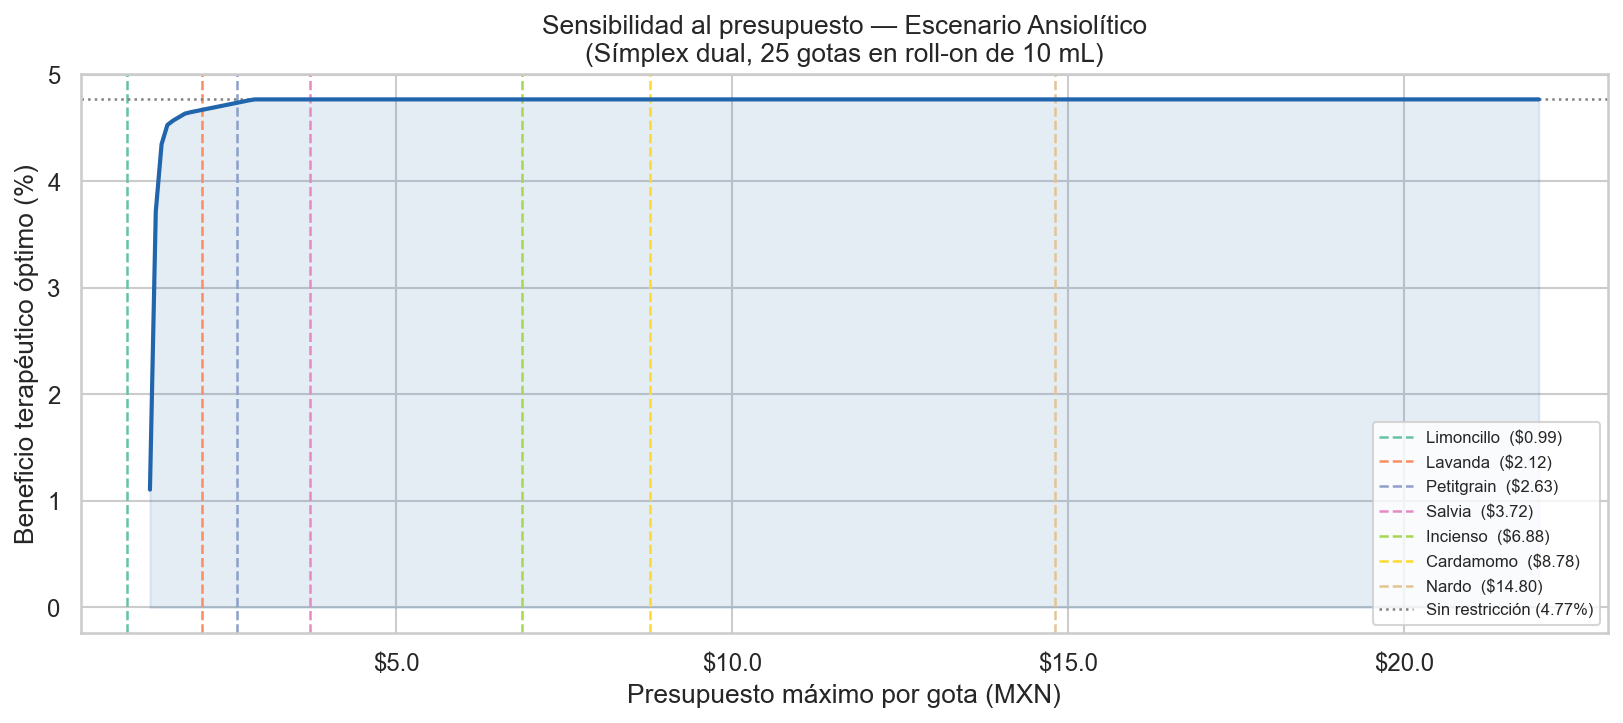

fig8_sensibilidad_presupuesto.png


In [91]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(budgets, benefit_arr, color="#2166ac", linewidth=2, zorder=3)
ax.fill_between(budgets, benefit_arr, alpha=0.12, color="#2166ac")

# Líneas verticales por precio de aceites clave
colors_oils = sns.color_palette("Set2", len(key_oils_anx))
for (oil, price), col in zip(sorted(key_oils_anx.items(), key=lambda kv: kv[1]), colors_oils):
    ax.axvline(price, color=col, linestyle="--", linewidth=1.2,
               label=f"{oil}  (${price:.2f})")

# Punto sin restricción de presupuesto
benefit_free = results["Ansiolítico"]["benefit_s"]
ax.axhline(benefit_free, color="gray", linestyle=":", linewidth=1.2,
           label=f"Sin restricción ({benefit_free:.2f}%)")

ax.set_xlabel("Presupuesto máximo por gota (MXN)")
ax.set_ylabel("Beneficio terapéutico óptimo (%)")
ax.set_title("Sensibilidad al presupuesto — Escenario Ansiolítico\n"
             "(Símplex dual, 25 gotas en roll-on de 10 mL)")
ax.legend(fontsize=8, loc="lower right")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.1f"))
plt.tight_layout()
plt.savefig(FIGS / "fig8_sensibilidad_presupuesto.png", bbox_inches="tight")
plt.show()
print("fig8_sensibilidad_presupuesto.png")

## 7. Variables Duales y Precios Sombra

El precio sombra de una restricción $g_k(\mathbf{x}) \leq b_k$ indica cuánto **mejoraría** el objetivo si se relaja $b_k$ en una unidad:

$$\lambda_k = \frac{\partial z^*}{\partial b_k}$$

- $\lambda_k > 0$ → restricción **activa** (binding); relajarla aumenta el beneficio.
- $\lambda_k = 0$ → restricción **inactiva**; no limita el óptimo actual.

In [92]:
def dual_analysis(scenario_name, budget_per_drop, method="highs-ds"):
    """
    Resuelve el LP con presupuesto y muestra los precios sombra.

    En linprog (minimización de -beneficio):
      r.ineqlin.marginals[k] = ∂(-beneficio*) / ∂b_k  (negativo cuando la restricción es activa y limita)
    Negamos para interpretar como "mejora en beneficio por unidad de relajación de b_k".
    """
    r, _ = solve_lp(scenario_name, budget_per_drop=budget_per_drop, method=method)

    if r.status != 0:
        print(f"LP no factible/óptimo: {r.message}")
        return

    actual_cost = float(p @ r.x)
    print(f"Escenario   : {scenario_name}")
    print(f"Presupuesto : ${budget_per_drop:.2f} / gota  (costo real: ${actual_cost:.4f} / gota)")
    print(f"Beneficio   : {-r.fun:.4f}%")
    print()

    # Solución óptima (aceites con fracción > 0.5%)
    x_ser = pd.Series(r.x, index=oils)
    active = x_ser[x_ser > 0.005].sort_values(ascending=False)
    print("  Aceites en la mezcla:")
    for oil, xv in active.items():
        print(f"    {oil:<20s}  {xv:.1%}  (${p[oils.index(oil)]:.4f}/gota)")

    # Precios sombra vía r.ineqlin.marginals  (disponible en scipy >= 1.7 con HiGHS)
    if hasattr(r, "ineqlin") and r.ineqlin is not None:
        n_cpd = len(restricted)
        lam = r.ineqlin.marginals       # negativo si la restricción limita la minimización
        lam_cpd    = -lam[:n_cpd]       # negamos → "mejora en beneficio por % de relajación"
        lam_budget = -lam[n_cpd]

        slack_cpd    = r.ineqlin.residual[:n_cpd]
        slack_budget = r.ineqlin.residual[n_cpd]

        print("\n  Restricciones de seguridad por compuesto:")
        for c, lc, sc in zip(restricted, lam_cpd, slack_cpd):
            status = "  ← ACTIVA" if abs(sc) < 1e-4 else ""
            print(f"    {c:<35s}  λ={lc:+.4f}  holgura={sc:.3f}%{status}")

        print(f"\n  Restricción de presupuesto  (B=${budget_per_drop:.2f}):")
        print(f"    λ = {lam_budget:+.4f}   holgura = ${slack_budget:.4f}")
        if abs(slack_budget) < 1e-4:
            print(f"    → Activa: por cada $1 MXN/gota adicional, el beneficio mejora ≈ {lam_budget:.4f}%")
        else:
            print(f"    → Inactiva: el presupuesto no restringe el óptimo actual.")

        # Precio sombra de la restricción de igualdad (λ de la función objetivo)
        lam_eq = r.eqlin.marginals[0]
        print(f"\n  Variable dual de igualdad (Σx=1): λ_eq = {lam_eq:.4f}")
    else:
        print("  Variables duales no disponibles.")


# Análisis con dos niveles de presupuesto
print("=" * 65)
dual_analysis(SCEN_BUDGET, budget_per_drop=2.50)
print("\n" + "=" * 65)
dual_analysis(SCEN_BUDGET, budget_per_drop=4.00)   # no binding

Escenario   : Anxiolytics [TC-therapeutic category]
Presupuesto : $2.50 / gota  (costo real: $2.5000 / gota)
Beneficio   : 4.7210%

  Aceites en la mezcla:
    Limón                 20.0%  ($1.0167/gota)
    Lavanda               20.0%  ($2.1167/gota)
    Albahaca              20.0%  ($2.0625/gota)
    Geranio               20.0%  ($2.7000/gota)
    Pimienta Negra        12.5%  ($6.5000/gota)
    Romero                7.5%  ($1.4417/gota)

  Restricciones de seguridad por compuesto:
    Eugenol                              λ=+0.0000  holgura=4.987%
    Thymol                               λ=+0.0000  holgura=2.500%
    Carvacrol                            λ=+0.0000  holgura=2.500%
    Citral                               λ=+0.0000  holgura=2.687%
    Neral                                λ=+0.0000  holgura=2.407%
    l-Menthol                            λ=+0.0000  holgura=50.000%
    Camphor                              λ=+0.0000  holgura=107.800%
    Linalool, (+/-)-                    

## 8. Símplex vs. Puntos Interiores — Comparación

Ambos métodos resuelven el mismo LP y deben llegar al **mismo valor óptimo**. La diferencia está en la trayectoria:

- **Símplex (HiGHS-DS)**: converge a un **vértice** del poliedro; solución típicamente dispersa (pocas variables activas).
- **Puntos Interiores (HiGHS-IPM)**: converge desde el interior; puede producir valores intermedios cerca del óptimo.

Comparamos tiempo de cómputo, dispersión de la solución ($\|x\|_0 > \varepsilon$) y diferencia numérica entre las dos soluciones.

In [93]:
REPS = 20   # repeticiones para medir tiempos estables
EPS  = 0.005

timing_rows = []
for label, d in results.items():
    scen_name = d["scen_name"]

    # Medir tiempos con múltiples repeticiones
    ts_list = [solve_lp(scen_name, method="highs-ds")[1] * 1000 for _ in range(REPS)]
    ti_list = [solve_lp(scen_name, method="highs-ipm")[1] * 1000 for _ in range(REPS)]

    xs = d["x_simplex"]
    xi = d["x_ipm"]

    timing_rows.append({
        "Escenario"      : label,
        "T_S med (ms)"   : f"{np.median(ts_list):.2f}",
        "T_S min (ms)"   : f"{np.min(ts_list):.2f}",
        "T_IPM med (ms)" : f"{np.median(ti_list):.2f}",
        "T_IPM min (ms)" : f"{np.min(ti_list):.2f}",
        "Ratio IPM/S"    : f"{np.median(ti_list) / np.median(ts_list):.2f}×",
        "‖x_S‖₀ (>ε)"   : int((xs > EPS).sum()),
        "‖x_I‖₀ (>ε)"   : int((xi > EPS).sum()),
        "‖x_S − x_I‖₂"  : f"{np.linalg.norm(xs - xi):.2e}",
        "Δ beneficio"    : f"{abs(d['benefit_s'] - d['benefit_i']):.2e}",
    })

df_cmp = pd.DataFrame(timing_rows)
print(f"Comparación Símplex vs. Puntos Interiores  ({REPS} repeticiones cada uno)\n")
display(df_cmp)

Comparación Símplex vs. Puntos Interiores  (20 repeticiones cada uno)



,Escenario,T_S med (ms),T_S min (ms),T_IPM med (ms),T_IPM min (ms),Ratio IPM/S,‖x_S‖₀ (>ε),‖x_I‖₀ (>ε),‖x_S − x_I‖₂,Δ beneficio
0,Ansiolítico,1.27,0.92,1.52,1.35,1.20×,5,5,0.00e+00,0.00e+00
1,Sueño,1.06,0.81,1.55,1.31,1.46×,6,6,0.00e+00,0.00e+00
2,Digestivo,1.13,0.85,1.22,1.18,1.08×,6,6,0.00e+00,0.00e+00


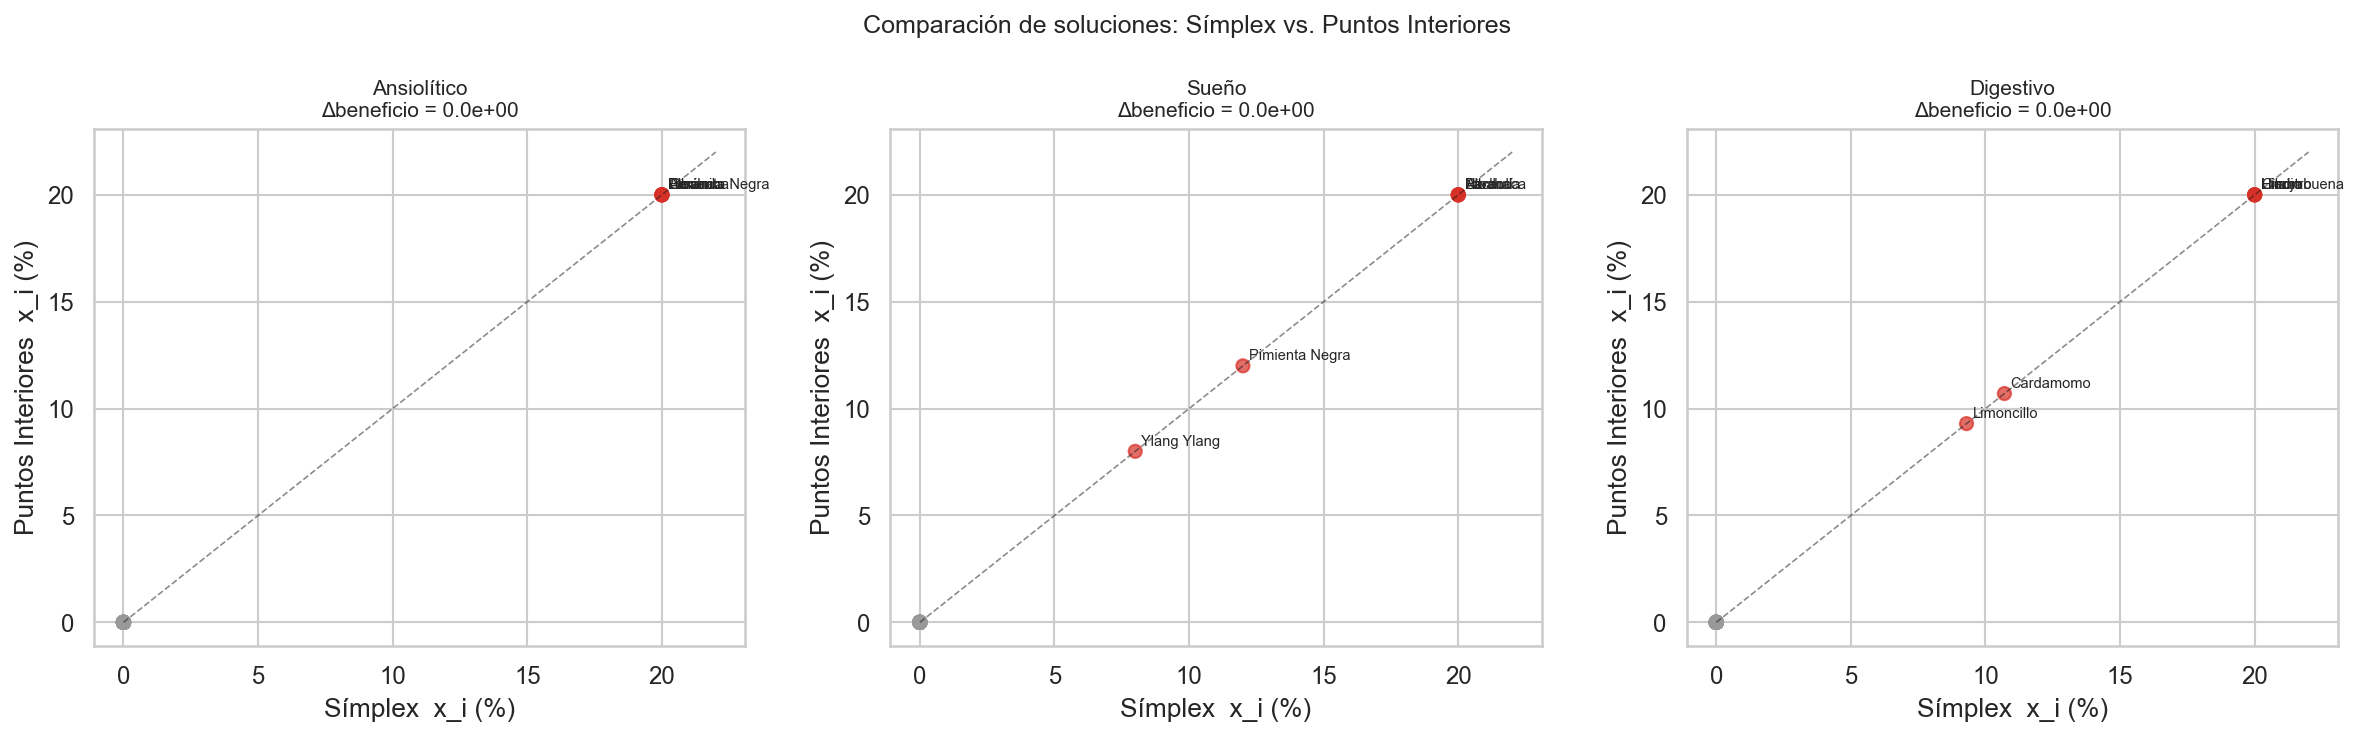

fig9_simplex_vs_ipm.png


In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, d) in zip(axes, results.items()):
    xs = d["x_simplex"]
    xi = d["x_ipm"]
    lim = max(xs.max(), xi.max()) * 1.1

    ax.scatter(xs * 100, xi * 100, s=40, alpha=0.7,
               color=["#d73027" if v > EPS else "#999999" for v in xs])
    ax.plot([0, lim * 100], [0, lim * 100], "k--", linewidth=0.8, alpha=0.5)

    # Etiquetar aceites con fracción > EPS
    for i, oil in enumerate(oils):
        if xs[i] > EPS or xi[i] > EPS:
            ax.annotate(oil, (xs[i] * 100, xi[i] * 100),
                        fontsize=7, xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel("Símplex  x_i (%)")
    ax.set_ylabel("Puntos Interiores  x_i (%)")
    ax.set_title(f"{label}\nΔbeneficio = {abs(d['benefit_s'] - d['benefit_i']):.1e}",
                 fontsize=10)

plt.suptitle("Comparación de soluciones: Símplex vs. Puntos Interiores", fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "fig9_simplex_vs_ipm.png", bbox_inches="tight")
plt.show()
print("fig9_simplex_vs_ipm.png")

## 9. Exportar Resultados

Guarda las mezclas óptimas de los tres escenarios (Símplex) en `data/clean/optimal_blends.csv`.

In [95]:
blend_rows = []
for label, d in results.items():
    x_ser = pd.Series(d["x_simplex"], index=oils)
    for oil, xv in x_ser.items():
        if xv > 1e-6:
            blend_rows.append({
                "escenario"     : label,
                "scen_key"      : d["scen_name"],
                "aceite"        : oil,
                "fraccion"      : round(xv, 6),
                "gotas_de_25"   : round(xv * 25, 2),
                "costo_parcial" : round(xv * price_ser.get(oil, 0), 4),
                "beneficio_contrib": round(
                    xv * float(A.loc[oil] @
                               scens.loc[d["scen_name"]].reindex(A.columns, fill_value=0).values /
                               max(scens.loc[d["scen_name"]].sum(), 1e-9)) / 100, 5
                ),
            })

df_blends = pd.DataFrame(blend_rows)
df_blends.to_csv(CLEAN / "optimal_blends.csv", index=False)
print("optimal_blends.csv guardado.\n")
display(df_blends.groupby("escenario").apply(
    lambda g: g.sort_values("fraccion", ascending=False)
).reset_index(drop=True))

optimal_blends.csv guardado.



C:\Users\pauli\AppData\Local\Temp\ipykernel_24832\4108993308.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  display(df_blends.groupby("escenario").apply(


,escenario,scen_key,aceite,fraccion,gotas_de_25,costo_parcial,beneficio_contrib
0,Ansiolítico,Anxiolytics [TC-therapeutic category],Limón,0.200000,5.00,0.2033,0.00255
1,Ansiolítico,Anxiolytics [TC-therapeutic category],Lavanda,0.200000,5.00,0.4233,0.03397
2,Ansiolítico,Anxiolytics [TC-therapeutic category],Albahaca,0.200000,5.00,0.4125,0.00499
3,Ansiolítico,Anxiolytics [TC-therapeutic category],Geranio,0.200000,5.00,0.5400,0.00285
4,Ansiolítico,Anxiolytics [TC-therapeutic category],Pimienta Negra,0.200000,5.00,1.3000,0.00334
5,Digestivo,Digestive Support,Limón,0.200000,5.00,0.2033,0.00445
6,Digestivo,Digestive Support,Cilantro,0.200000,5.00,0.5083,0.00440
7,Digestivo,Digestive Support,Hierbabuena,0.200000,5.00,0.5875,0.00616
8,Digestivo,Digestive Support,Hinojo,0.200000,5.00,0.2933,0.01161
9,Digestivo,Digestive Support,Cardamomo,0.107037,2.68,0.9393,0.00179


## 10. Discusión: Aprendizajes y Dificultades

Lo que más nos costó trabajo al principio fue entender por qué el Símplex siempre devolvía mezclas con exactamente 3 aceites al 40%. Tiene sentido en retrospectiva —el LP va a un vértice y con cotas de 40% la aritmética solo deja espacio para ~2.5 aceites— pero nos tomó un rato distinguir si era un bug o un comportamiento esperado. Bajar `U_MAX_CAP` a 0.20 resolvió el problema de diversidad.

Otro obstáculo fue con las variables duales. La documentación de scipy menciona `res.ineq_marginals`, pero ese atributo no existe en la versión 1.13.1. Lo encontramos con un script de inspección: el correcto es `res.ineqlin.marginals`. Es el tipo de diferencia entre versiones que no está en los tutoriales y que solo aparece cuando ya llevas un rato buscando por qué el código no funciona.

También tardamos en procesar que doce pares de escenarios producen exactamente la misma mezcla. Primero lo revisamos como posible error en la construcción del c-vector; después vimos que la correlación era 1.0 exacta y que las mismas plantas aparecen en scentindb bajo dos nombres de uso distintos. No es un error del modelo, pero tampoco lo teníamos anticipado.

**Limitaciones del modelo**

El vector $\mathbf{c}$ se construye por co-ocurrencia en la literatura (qué plantas se asocian a qué uso terapéutico) y no por evidencia directa de que cada compuesto cause el efecto. Es un proxy razonable pero no un modelo clínico. Además, el LP asume que el beneficio de la mezcla es la suma lineal de los individuales — ignora sinergias y antagonismos entre compuestos, que en fitoterapia pueden ser relevantes.

Las soluciones también tienden a ser extremas: la mayoría de los aceites quedan en 0% o en su cota máxima. Para recomendaciones reales habría que agregar restricciones de mínima inclusión (lo que requeriría un MILP) o un término de regularización en el objetivo.

Por último, ~6 aceites del catálogo doTERRA no tienen datos GC-MS en scentindb (Vetiver, Manzanilla Romana, Bergamota, entre otros), así que no contribuyen en ningún escenario. Eso limita algunas mezclas que en aromaterapia tradicional sí incluirían esos aceites.

**Conclusión**

El LP captura la estructura del problema de forma natural y los 59 escenarios se resuelven en menos de un segundo. La parte más interesante fue ver que las restricciones de seguridad (eugenol, timol) son las que más frecuentemente limitan el óptimo — no el presupuesto. Eso dice algo real sobre por qué los aceites más potentes antimicrobialmente son también los que más cuidado requieren en formulación. En cuanto a Símplex vs. Puntos Interiores: para este tamaño de problema ($n=30$, $m \approx 10$) son equivalentes en calidad de solución; la diferencia teórica de complejidad solo importaría a una escala mucho mayor.

## Referencias

1. **Vanderbei, R. J.** (2020). *Linear Programming: Foundations and Extensions* (5th ed.). Springer. — Formulación estándar, dualidad, Símplex.

2. **Wright, S. J.** (1997). *Primal-Dual Interior-Point Methods*. SIAM. — Método de barrera logarítmica, camino central, paso de Newton predictor-corrector.

3. **Nocedal, J. & Wright, S. J.** (2006). *Numerical Optimization* (2nd ed.). Springer. — Capítulos 13–14: métodos de puntos interiores para PL.

4. **Huangfu, Q. & Hall, J. A. J.** (2018). Parallelizing the dual revised simplex method. *Mathematical Programming Computation*, 10(1), 119–142. — Fundamentos del solver HiGHS (`highs-ds`, `highs-ipm`).

5. **Tisserand, R. & Young, R.** (2014). *Essential Oil Safety: A Guide for Health Care Professionals* (2nd ed.). Churchill Livingstone. — Límites dermales por aceite ($u_i$).

6. **IFRA** (2023). *IFRA Standards Amendment 49 — Category 5B (Leave-on body)*. International Fragrance Association. — Límites de compuestos restringidos ($d_j^{\max}$).

7. **Naef, R. et al.** (2011). *The volatile and semi-volatile constituents of agarwood, the infectiously diseased heartwood of Aquilaria species*. Flavour and Fragrance Journal — y demás referencias originales de la base de datos **ScentInDB**: [https://scentindb.cedric-linder.com](https://scentindb.cedric-linder.com)

8. **SciPy Contributors** (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. — `scipy.optimize.linprog` con backend HiGHS.